# PMM-style strategy — **crypto universe**

Same mathematical pipeline as `pmm_strategy.ipynb` (RPM, vol targeting, PMM/PMMC), with **crypto data** replacing Kenneth French deciles and FF factors.

**Data source:** [Binance](https://www.binance.com) spot market via **`ccxt`** (public OHLCV; API keys only if you later add private endpoints). Yahoo / `yfinance` is not used.

Constants and bar conventions are documented in each cell; results are **not** comparable to the equity paper line-by-line.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera, skew, kurtosis
import numexpr as ne
import numba
from numba import jit, prange
import joblib
from joblib import Parallel, delayed
import os
import time

# Crypto: Binance spot via ccxt (public klines; rate-limit enabled). pip install ccxt
try:
    import ccxt
    binance = ccxt.binance({"enableRateLimit": True, "options": {"defaultType": "spot"}})
except ImportError:
    ccxt = None
    binance = None

# --- display config (same as equity notebook) ---
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# --- global constants (same economic definitions as paper notebook) ---
# Bar convention for crypto: we use UTC daily close bars unless a cell says otherwise.
SIGMA_TAR  = 0.12       # annualized target volatility (12%)
RPM_WINDOW = 126        # 126 *calendar days* of daily returns for RPM (~4.1 months)
# Annualization fix vs equity paper: crypto trades 365 days/yr, equity 252. Equity SCALE
# = 21/126 sets 12*RV = 252*mean(r^2) = annualized variance under a 252-day year. With
# crypto daily bars that understates true ann. variance by 252/365, so sqrt(12*RV) is
# ~17% too small and leverage = sigma_tar/sqrt(12*RV) ends up ~20% too high. Using
# SCALE = (365/12)/126 makes 12*RV = (365/126)*sum(r^2) = annualized variance exactly,
# keeping the paper formula sqrt(12*RV) intact while targeting the 12% vol correctly.
SCALE      = (365 / 12) / 126  # crypto monthly-variance scaler (365-day calendar year)
FORM_START = 12         # formation: t-12 (in months for monthly ranks; daily path may rescale)
FORM_END   = 2          # formation: t-2 (skip t-1)
MAX_LEV    = 2.0      # 200% leverage cap for PMMC

# Separate cache from equity notebook to avoid mixing parquet files
CACHE_DIR  = r'C:\Users\User\Documents\pmm\cache_crypto'
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"numpy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"numba      : {numba.__version__}")
print(f"numexpr    : {ne.__version__}")
print(f"joblib     : {joblib.__version__}")
print(f"ccxt       : {ccxt.__version__ if ccxt else 'not installed (pip install ccxt)'}")
print(f"Binance id : {binance.id if binance else 'n/a'}")
print(f"numexpr threads : {ne.detect_number_of_cores()} cores detected")
print(f"numba threads   : {numba.get_num_threads()} threads")
print()
print("--- Strategy constants (aligned with paper notebook) ---")
print(f"  SIGMA_TAR  = {SIGMA_TAR}  (12% ann. target vol)")
print(f"  RPM_WINDOW = {RPM_WINDOW} calendar days (~4.1 months daily RPM)")
print(f"  SCALE      = {SCALE:.6f}  ((365/12)/126; 12*RV = annualized variance, 365-day yr)")
print(f"  FORM       = t-{FORM_START} to t-{FORM_END}  (skip t-1)")
print(f"  MAX_LEV    = {MAX_LEV}")
print(f"  CACHE_DIR  = {CACHE_DIR}")


numpy      : 2.3.5
pandas     : 2.3.3
numba      : 0.62.1
numexpr    : 2.14.1
joblib     : 1.5.2
ccxt       : 4.5.53
Binance id : binance
numexpr threads : 16 cores detected
numba threads   : 16 threads

--- Strategy constants (aligned with paper notebook) ---
  SIGMA_TAR  = 0.12  (12% ann. target vol)
  RPM_WINDOW = 126 calendar days (~4.1 months daily RPM)
  SCALE      = 0.241402  ((365/12)/126; 12*RV = annualized variance, 365-day yr)
  FORM       = t-12 to t-2  (skip t-1)
  MAX_LEV    = 2.0
  CACHE_DIR  = C:\Users\User\Documents\pmm\cache_crypto


In [2]:
# =============================================================================
# CELL 2 — Data download (Binance spot, daily UTC via ccxt)
# Universe: **weighted liquidity rank** then walk-down with **min history**.
#   (1) Eligible USDT spot pairs, sorted by Binance **24h quoteVolume**.
#   (2) Shortlist top CANDIDATE_POOL; for each, fetch last QUOTE_VOL_WINDOW daily
#       bars and score **sum(close * volume)** as a ~monthly turnover proxy.
#   (3) Blend: VOL_BLEND_SHORT * norm(24h) + VOL_BLEND_LONG * norm(trailing).
#   (4) Walk blended order; keep MIN_DAILY_BARS + min listing age on full OHLCV.
# MKT_SYMBOL is walked **first**.
#
# Universe filter philosophy (point-in-time, no static survivor filter):
# MIN_LISTING_AGE_DAYS=365 is just the **snapshot** filter - "is this coin old
# enough today that it could contribute to ANY past WML signal?". The strategy
# formation window needs 12 months of history, so a coin that is <365 days old
# today wouldn't be eligible at ANY past rebalance T anyway. The per-rebalance
# eligibility ("at month T, has this coin been listed for >=12 months as of
# T?") is enforced in Cell 6 (math layer) and Cell 12 (engine strategy) via
# point-in-time checks. So SOL (listed Aug 2020) becomes eligible from Aug
# 2021 onwards but is *excluded* from earlier cross-sections - no look-ahead.
#
# Note on remaining selection bias: the top-N **liquidity ranking** uses
# *today's* quoteVolume + trailing-30d turnover. Full PIT ranking would
# re-rank monthly from historical candles for ALL USDT pairs - too expensive
# without a wholesale klines database. Standard published-paper compromise.
#
# Outputs: UNIVERSE, ohlcv_daily, closes, common_idx, universe_snapshot.csv
# Set FORCE_REFRESH = True to re-fetch OHLCV (ignores per-symbol parquet cache).
# =============================================================================

if binance is None:
    raise RuntimeError("Run Cell 1 first; ccxt / binance client is missing.")

FORCE_REFRESH = False  # True = re-download OHLCV for every symbol we touch (ignore parquet)
# Cache hygiene: (1) Universe *ranking* uses tickers + short 30d klines - not old parquets.
# (2) Full-history OHLCV comes from parquet if present; a *short* cached series still
#     fails MIN_DAILY_BARS and is skipped (won't enter UNIVERSE). (3) Parquet files for
#     symbols we never walk again are inert (disk only). Use FORCE_REFRESH=True once
#     after changing MIN_DAILY_BARS or if you suspect a bad/stale file.
MKT_SYMBOL = "BTC/USDT"
UNIVERSE_SIZE = 50         # broader pool so younger coins can aging-in over time
# --- liquidity ranking (24h snapshot + trailing daily turnover proxy) ---
CANDIDATE_POOL = 250       # how many top-24h names get the trailing-volume API pass
QUOTE_VOL_WINDOW = 30    # calendar days of daily bars for long leg (~1 month)
VOL_BLEND_SHORT = 0.35   # weight on 24h quote volume (noisy, catches new hype)
VOL_BLEND_LONG = 0.65    # weight on trailing dollar-volume proxy (smoother)

_EXCLUDE_BASES = {
    "USDT", "USDC", "FDUSD", "BUSD", "DAI", "TUSD", "USDP", "PYUSD", "USDD",
    "EUR", "GBP", "TRY", "BRL", "AUD", "IDR", "UAH", "ARS", "MXN", "PLN", "RON",
    "XUSD", "USD1", "RLUSD", "USDE", "EURC", "WBTC",
}


def _cache_path(symbol: str, timeframe: str = "1d") -> str:
    safe = symbol.replace("/", "_").lower()
    return os.path.join(CACHE_DIR, f"{safe}_{timeframe}.parquet")


def _fetch_ohlcv_daily_full(symbol: str) -> pd.DataFrame:
    """Paginate Binance daily candles until the present (public API)."""
    rows = []
    since = binance.parse8601("2017-01-01T00:00:00Z")
    ms_day = 86_400_000
    while True:
        batch = binance.fetch_ohlcv(symbol, "1d", since=since, limit=1000)
        if not batch:
            break
        rows.extend(batch)
        since = batch[-1][0] + ms_day
        if len(batch) < 1000:
            break
    df = pd.DataFrame(
        rows,
        columns=["timestamp", "open", "high", "low", "close", "volume"],
    )
    df["date"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("date").sort_index()
    df = df[["open", "high", "low", "close", "volume"]].astype("float64")
    df = df[~df.index.duplicated(keep="last")]
    return df


def download_or_load_crypto(symbol: str) -> pd.DataFrame:
    path = _cache_path(symbol)
    if os.path.exists(path) and not FORCE_REFRESH:
        print(f"  [cache] {symbol}")
        return pd.read_parquet(path)
    print(f"  [download] {symbol} ...")
    t0 = time.perf_counter()
    df = _fetch_ohlcv_daily_full(symbol)
    df.to_parquet(path)
    print(f"           done in {time.perf_counter() - t0:.1f}s, shape={df.shape}")
    return df


def rank_usdt_spot_by_volume(exchange):
    """Eligible USDT spot symbols with 24h quote volume (unsorted list as DataFrame + rows)."""
    exchange.load_markets()
    tickers = exchange.fetch_tickers()
    ranked = []
    for sym, m in exchange.markets.items():
        if not m.get("active") or not m.get("spot"):
            continue
        if m.get("quote") != "USDT" or m.get("type") != "spot":
            continue
        base = m.get("base", "")
        if base in _EXCLUDE_BASES:
            continue
        if not str(base).isascii():
            continue
        if any(x in sym for x in ("UP/USDT", "DOWN/USDT", "BULL/USDT", "BEAR/USDT")):
            continue
        t = tickers.get(sym) or {}
        qv = t.get("quoteVolume")
        try:
            qv = float(qv) if qv is not None else 0.0
        except (TypeError, ValueError):
            qv = 0.0
        ranked.append((sym, qv, base))
    ranked.sort(key=lambda x: -x[1])
    meta = pd.DataFrame(ranked, columns=["symbol", "quote_volume_24h", "base"])
    return meta, ranked


def _tail_dollar_volume_sum(exchange, symbol: str, n_days: int) -> float:
    """Sum(close * volume) over last n_days daily candles (one API call)."""
    try:
        ohlcv = exchange.fetch_ohlcv(symbol, "1d", limit=max(n_days + 5, 35))
    except Exception:
        return float("nan")
    if not ohlcv:
        return float("nan")
    arr = np.asarray(ohlcv, dtype=np.float64)
    c, v = arr[:, 4], arr[:, 5]
    tail = min(n_days, len(c))
    c, v = c[-tail:], v[-tail:]
    return float(np.nansum(c * v))


def weighted_liquidity_walk_order(exchange, ranked_rows: list, mkt: str):
    """Shortlist by 24h vol, add trailing dollar-volume score, return walk order (mkt first)."""
    shortlist = [r[0] for r in ranked_rows[:CANDIDATE_POOL]]
    rows = []
    print(f"  [rank] scoring trailing {QUOTE_VOL_WINDOW}d $volume for {len(shortlist)} candidates ...")
    t0 = time.perf_counter()
    qv_map = {r[0]: r[1] for r in ranked_rows}
    for sym in shortlist:
        liq = _tail_dollar_volume_sum(exchange, sym, QUOTE_VOL_WINDOW)
        rows.append({"symbol": sym, "quote_volume_24h": qv_map.get(sym, 0.0), "trail_dollar_vol": liq})
    score_df = pd.DataFrame(rows)
    qv = np.log1p(np.maximum(score_df["quote_volume_24h"].to_numpy(dtype=np.float64), 0.0))
    lq = np.log1p(np.nan_to_num(score_df["trail_dollar_vol"].to_numpy(dtype=np.float64), nan=0.0, posinf=0.0, neginf=0.0))
    def _norm(x):
        lo, hi = np.nanmin(x), np.nanmax(x)
        if hi - lo < 1e-18:
            return np.zeros_like(x)
        return (x - lo) / (hi - lo)
    qv_n, lq_n = _norm(qv), _norm(lq)
    w_s, w_l = VOL_BLEND_SHORT, VOL_BLEND_LONG
    wsum = w_s + w_l
    score_df["blend_score"] = (w_s * qv_n + w_l * lq_n) / wsum
    score_df = score_df.sort_values("blend_score", ascending=False)
    ordered = [s for s in score_df["symbol"].tolist() if s != mkt]
    seen = set([mkt]) | set(ordered)
    tail = [r[0] for r in ranked_rows if r[0] not in seen]
    walk = [mkt] + ordered + tail
    print(f"           done in {time.perf_counter() - t0:.1f}s")
    return walk, score_df


# MIN_DAILY_BARS just rejects degenerate/gappy parquets; the listing-age check is what
# actually filters by date-of-first-bar. 400 bars ~ 1.1 years (small buffer vs the
# 1-year minimum so coins straddling exactly 365 days are not excluded by gaps).
MIN_DAILY_BARS = max(400, int(RPM_WINDOW * 3))
# First daily bar must be at least this many calendar days before this notebook run (UTC).
MIN_LISTING_AGE_DAYS = 365         # 1 year minimum (point-in-time eligibility enforced downstream)
LISTING_ASOF = pd.Timestamp.now(tz="UTC").normalize()
_min_first_allowed = LISTING_ASOF - pd.Timedelta(days=MIN_LISTING_AGE_DAYS)
print(
    f"  [info] listing age: first bar <= {_min_first_allowed.date()} "
    f"({MIN_LISTING_AGE_DAYS}d before LISTING_ASOF={LISTING_ASOF.date()} UTC)"
)

_univ_rank, ranked_rows = rank_usdt_spot_by_volume(binance)
walk_order, _score_df = weighted_liquidity_walk_order(
    binance, ranked_rows, MKT_SYMBOL
)
_score_path = os.path.join(CACHE_DIR, "universe_liquidity_scores.csv")
_score_df.to_csv(_score_path, index=False)
print(f"  [rank] full shortlist scores: {_score_path}")

ohlcv_daily = {}
UNIVERSE = []
_attempts = 0
_max_attempts = 500
for sym in walk_order:
    if len(UNIVERSE) >= UNIVERSE_SIZE:
        break
    _attempts += 1
    if _attempts > _max_attempts:
        raise RuntimeError(
            f"Could not fill UNIVERSE_SIZE={UNIVERSE_SIZE} with >= {MIN_DAILY_BARS} daily bars each. "
            "Lower MIN_DAILY_BARS or UNIVERSE_SIZE."
        )
    try:
        df = download_or_load_crypto(sym)
    except Exception as exc:
        print(f"  [skip] {sym}  fetch error: {exc}")
        continue
    if len(df) < MIN_DAILY_BARS:
        print(f"  [skip] {sym}  bars={len(df)} < MIN_DAILY_BARS={MIN_DAILY_BARS}")
        continue
    _first = pd.Timestamp(df.index[0])
    if _first.tzinfo is None:
        _first = _first.tz_localize("UTC")
    else:
        _first = _first.tz_convert("UTC")
    if _first > _min_first_allowed:
        print(
            f"  [skip] {sym}  first_bar={_first.date()} after cutoff {_min_first_allowed.date()} "
            f"(need >= {MIN_LISTING_AGE_DAYS}d since first daily vs this run)"
        )
        continue
    ohlcv_daily[sym] = df
    UNIVERSE.append(sym)

if len(UNIVERSE) < UNIVERSE_SIZE:
    raise RuntimeError(
        f"Only {len(UNIVERSE)} symbols passed filters (need {UNIVERSE_SIZE}). "
        f"MIN_DAILY_BARS={MIN_DAILY_BARS}, MIN_LISTING_AGE_DAYS={MIN_LISTING_AGE_DAYS}. "
        "Either lower UNIVERSE_SIZE or relax MIN_LISTING_AGE_DAYS."
    )

_snap = _score_df[_score_df["symbol"].isin(UNIVERSE)].copy()
_snap = _snap.sort_values("blend_score", ascending=False)
_snap["min_daily_bars_required"] = MIN_DAILY_BARS
_snap["vol_blend_short"] = VOL_BLEND_SHORT
_snap["vol_blend_long"] = VOL_BLEND_LONG
_snap["min_listing_age_days"] = MIN_LISTING_AGE_DAYS
_snap["listing_asof_utc"] = str(LISTING_ASOF.date())
_snap_path = os.path.join(CACHE_DIR, "universe_snapshot.csv")
_snap.to_csv(_snap_path, index=False)

print("=== Universe (weighted liquidity rank + min-history walk-down) ===")
print(
    f"  UNIVERSE_SIZE={UNIVERSE_SIZE}  MIN_DAILY_BARS={MIN_DAILY_BARS}  "
    f"MIN_LISTING_AGE={MIN_LISTING_AGE_DAYS}d  blend={VOL_BLEND_SHORT:.2f}*24h + {VOL_BLEND_LONG:.2f}*{QUOTE_VOL_WINDOW}d$vol"
)
print(f"  MKT_SYMBOL={MKT_SYMBOL}")
print(f"  snapshot: {_snap_path}")
print(f"  walk attempts={_attempts}")
print(f"  selected ({len(UNIVERSE)}): {UNIVERSE}")
print()

print("=== Daily OHLCV shapes and UTC date ranges (sample) ===")
for sym in UNIVERSE[:5]:
    df = ohlcv_daily[sym]
    print(f"  {sym:14s} shape={str(df.shape):14s} {df.index[0].date()} -> {df.index[-1].date()}")
if len(UNIVERSE) > 8:
    print("  ...")
for sym in UNIVERSE[-3:]:
    df = ohlcv_daily[sym]
    print(f"  {sym:14s} shape={str(df.shape):14s} {df.index[0].date()} -> {df.index[-1].date()}")
print(f"  (all {len(UNIVERSE)} symbols loaded; use ohlcv_daily[sym] for any row)")

# Wide panel: union of all dates where at least one coin trades.
# NaN survives for each coin BEFORE its listing - downstream cells use this
# to enforce point-in-time eligibility per coin per month.
closes = pd.DataFrame({s: d["close"] for s, d in ohlcv_daily.items()}).sort_index()
common_idx = closes.dropna(how="all").index   # rows where at least one coin has a price
print()
print(f"=== Common daily index (any-coin-trading) ===")
print(f"  bars={len(common_idx)}  {common_idx[0].date()} -> {common_idx[-1].date()}")
_listing = pd.Series({s: ohlcv_daily[s].index[0] for s in UNIVERSE}).sort_values()
print(f"  earliest listings: {_listing.head(3).to_dict()}")
print(f"  latest   listings: {_listing.tail(3).to_dict()}")

print()
print(f"=== RPM market proxy ===  {MKT_SYMBOL}  (same series in ohlcv_daily)")


  [info] listing age: first bar <= 2025-05-17 (365d before LISTING_ASOF=2026-05-17 UTC)
  [rank] scoring trailing 30d $volume for 250 candidates ...
           done in 66.1s
  [rank] full shortlist scores: C:\Users\User\Documents\pmm\cache_crypto\universe_liquidity_scores.csv
  [cache] BTC/USDT
  [cache] ETH/USDT
  [cache] SOL/USDT
  [cache] XRP/USDT
  [cache] ZEC/USDT
  [cache] DOGE/USDT
  [cache] BNB/USDT
  [cache] SUI/USDT
  [cache] TON/USDT
  [cache] CHIP/USDT
  [skip] CHIP/USDT  bars=23 < MIN_DAILY_BARS=400
  [cache] TRX/USDT
  [cache] PEPE/USDT
  [cache] TAO/USDT
  [cache] LINK/USDT
  [cache] SPK/USDT
  [skip] SPK/USDT  bars=331 < MIN_DAILY_BARS=400
  [cache] ADA/USDT
  [cache] LUNC/USDT
  [cache] NEAR/USDT
  [cache] U/USDT
  [skip] U/USDT  bars=121 < MIN_DAILY_BARS=400
  [cache] AAVE/USDT
  [cache] AVAX/USDT
  [cache] ONDO/USDT
  [skip] ONDO/USDT  bars=398 < MIN_DAILY_BARS=400
  [cache] LTC/USDT
  [cache] LAYER/USDT
  [cache] PENGU/USDT
  [cache] SAGA/USDT
  [cache] UNI/USDT
  [

In [4]:
# =============================================================================
# CELL 2.5 — Point-in-time universe via Binance Vision archive
# Replaces the snapshot UNIVERSE from Cell 2 with a TIME-VARYING universe:
# at each rebalance month T, the universe is the top-PIT_UNIVERSE_SIZE coins
# by trailing-LIQ_LOOKBACK_DAYS dollar-volume *AS OF T* - no survivor bias.
#
# Binance Vision (data.binance.vision) is Binance's public S3 archive of
# historical klines. Unlike the ccxt API which only serves currently-listed
# pairs, Vision has data for EVERY USDT spot pair that ever existed - active
# AND delisted (LUNA, FTT, BUSD, etc.). This is what removes the survivor bias.
#
# IMPORTANT: Binance Vision changed timestamp resolution mid-history (some
# coins migrated from millisecond -> microsecond open_time around late 2024
# / early 2025). BTCUSDT specifically: 2017-2024 files use 13-digit ms,
# 2025+ files use 16-digit us. So we MUST detect the unit per-file (looking
# at THAT file's values) and convert to a datetime column *before* concat.
#
# Pipeline:
#   (1) Scrape S3 listing for all USDT spot symbols ever published (~900).
#   (2) For each symbol, list and download all monthly 1d-kline zips in
#       parallel; parse each CSV with per-file unit detection (ms / us / s);
#       aggregate to one OHLCV DataFrame indexed by date; cache parquet.
#   (3) Sanity-retry: ESSENTIAL_SYMBOLS missing from HIST_OHLCV get retried.
#   (4) Build wide trailing-30d dollar-volume matrix.
#   (5) PIT_UNIVERSE[Period[M]] = top-N at each month-end by that trailing $vol.
#   (6) SUPER_UNIVERSE = union of all PIT universes.
#   (7) Override UNIVERSE / ohlcv_daily / closes / common_idx with SUPER_UNIVERSE.
#
# First run: 15-30 min. Cached per-symbol parquet after.
# Set FORCE_REFRESH_HIST=True to redo everything.
# IF YOUR LAST RUN WAS INTERRUPTED: just re-run; parquet cache resumes.
# =============================================================================

import requests
import zipfile as _zipfile
import io as _io
import xml.etree.ElementTree as _ET
from concurrent.futures import ThreadPoolExecutor, as_completed

VISION_BUCKET = "https://s3-ap-northeast-1.amazonaws.com/data.binance.vision"
VISION_CDN    = "https://data.binance.vision"
_S3_NS        = "{http://s3.amazonaws.com/doc/2006-03-01/}"
HIST_CACHE_DIR = os.path.join(CACHE_DIR, "vision_hist")
os.makedirs(HIST_CACHE_DIR, exist_ok=True)

FORCE_REFRESH_HIST    = False
PIT_UNIVERSE_SIZE     = 50
LIQ_LOOKBACK_DAYS     = 30
PIT_PARALLEL_WORKERS  = 20
PIT_MIN_DAYS_FOR_COIN = 30

ESSENTIAL_SYMBOLS = ("BTCUSDT", "ETHUSDT", "BNBUSDT")


def _hist_cache(sym):
    return os.path.join(HIST_CACHE_DIR, f"{sym.lower()}_1d.parquet")


def _s3_iter_pages(prefix, want_subdirs):
    """Iterate S3 listing pages. Yields (subdirs, file_keys) per page."""
    marker = ""
    while True:
        params = [f"prefix={prefix}"]
        if want_subdirs:
            params.append("delimiter=/")
        if marker:
            params.append(f"marker={marker}")
        url = f"{VISION_BUCKET}/?{'&'.join(params)}"
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        root = _ET.fromstring(r.text)
        subs = [p.text for p in root.findall(f"{_S3_NS}CommonPrefixes/{_S3_NS}Prefix")]
        keys = [c.text for c in root.findall(f"{_S3_NS}Contents/{_S3_NS}Key")]
        yield subs, keys
        is_trunc = root.find(f"{_S3_NS}IsTruncated")
        if is_trunc is None or is_trunc.text != "true":
            return
        nm = root.find(f"{_S3_NS}NextMarker")
        if nm is not None and nm.text:
            marker = nm.text
        elif subs:
            marker = subs[-1]
        elif keys:
            marker = keys[-1]
        else:
            return


def discover_usdt_spot_symbols():
    """All USDT spot symbols Binance Vision has ever published."""
    syms = []
    for subs, _ in _s3_iter_pages("data/spot/monthly/klines/", want_subdirs=True):
        for d in subs:
            sym = d.rstrip("/").rsplit("/", 1)[-1]
            if sym.endswith("USDT"):
                syms.append(sym)
    bad_suffixes = ("UPUSDT", "DOWNUSDT", "BULLUSDT", "BEARUSDT")
    syms = [s for s in syms
            if not any(s.endswith(b) for b in bad_suffixes)
            and s[:-4] not in _EXCLUDE_BASES]
    return sorted(set(syms))


def list_vision_months(sym):
    """All monthly 1d-kline zip keys for a symbol."""
    keys = []
    for _, page_keys in _s3_iter_pages(
        f"data/spot/monthly/klines/{sym}/1d/", want_subdirs=False
    ):
        for k in page_keys:
            if k.endswith(".zip"):
                keys.append(k)
    return sorted(keys)


def _detect_time_unit(values):
    """Guess datetime unit from a Series of integer epoch values.

    ~1e10 -> s, ~1e13 -> ms, ~1e16 -> us, ~1e19 -> ns.
    Uses the max non-NaN value (post-2020 timestamps are bigger than 2017 ones).
    Defaults to 'ms' if values are clearly ms-scale (~1e12-1e13).
    """
    v = pd.to_numeric(values, errors="coerce").dropna()
    if len(v) == 0:
        return "ms"
    mx = float(v.max())
    if mx > 1e17:
        return "ns"
    if mx > 1e14:
        return "us"
    if mx > 1e11:
        return "ms"
    return "s"


def _parse_vision_csv(content_bytes):
    """Parse Vision daily-kline CSV (header or headerless) to DataFrame.

    Each CSV uses ONE timestamp unit internally; detect it from this file's
    values and convert open_time -> 'date' (datetime64[ns, UTC]) inline.
    This is critical because some symbols' monthly zips span Binance's
    ms->us migration; concatenating raw open_time first would mix units.
    """
    text = content_bytes.decode("utf-8", errors="ignore")
    if not text.strip():
        return None
    first_line = text.splitlines()[0]
    first_field = first_line.split(",")[0].strip().lstrip("-")
    has_header = not first_field.replace(".", "", 1).isdigit()
    if has_header:
        df = pd.read_csv(_io.StringIO(text))
    else:
        df = pd.read_csv(
            _io.StringIO(text),
            header=None,
            names=[
                "open_time", "open", "high", "low", "close", "volume",
                "close_time", "quote_volume", "n_trades",
                "taker_buy_base_volume", "taker_buy_quote_volume", "ignore",
            ],
        )
    df.columns = [
        (c.lower().replace(" ", "_") if isinstance(c, str) else c)
        for c in df.columns
    ]
    if "open_time" not in df.columns:
        return None
    unit = _detect_time_unit(df["open_time"])
    try:
        df["date"] = pd.to_datetime(df["open_time"], unit=unit, utc=True)
    except (OverflowError, ValueError, Exception):
        return None
    return df


def _download_zip(key):
    """Download a Vision zip and return its first CSV as a DataFrame (or None)."""
    url = f"{VISION_CDN}/{key}"
    try:
        r = requests.get(url, timeout=60)
        if r.status_code != 200:
            return None
        with _zipfile.ZipFile(_io.BytesIO(r.content)) as zf:
            for n in zf.namelist():
                if n.endswith(".csv"):
                    return _parse_vision_csv(zf.read(n))
    except Exception:
        return None
    return None


def fetch_symbol_hist(sym):
    """Aggregate all monthly 1d klines for sym into one DataFrame; cache parquet.

    Each monthly DataFrame already has a 'date' column (datetime64) computed
    with that file's correct unit (ms or us). We concat on 'date' so mixed
    units across files Just Work.
    """
    cache = _hist_cache(sym)
    if os.path.exists(cache) and not FORCE_REFRESH_HIST:
        try:
            return pd.read_parquet(cache)
        except Exception:
            pass
    try:
        keys = list_vision_months(sym)
    except Exception:
        return None
    if not keys:
        return None
    parts = []
    for k in keys:
        df = _download_zip(k)
        if df is not None and len(df) and "date" in df.columns:
            parts.append(df)
    if not parts:
        return None
    full = pd.concat(parts, ignore_index=True)
    if "date" not in full.columns:
        return None
    full = full.dropna(subset=["date"])
    full = full.drop_duplicates(subset=["date"]).sort_values("date")
    full = full.set_index("date")
    cols = [c for c in ["open", "high", "low", "close", "volume", "quote_volume"] if c in full.columns]
    if not cols:
        return None
    out = full[cols].astype("float64")
    out.to_parquet(cache)
    return out


# === Step 1: discover all symbols ===
print("[discover] listing Binance Vision USDT spot symbols ...")
t0 = time.perf_counter()
all_symbols = discover_usdt_spot_symbols()
for ess in ESSENTIAL_SYMBOLS:
    if ess not in all_symbols:
        all_symbols.append(ess)
all_symbols = sorted(set(all_symbols))
print(f"  {len(all_symbols)} symbols discovered in {time.perf_counter()-t0:.1f}s")
print(f"  sample: {all_symbols[:3]} ... {all_symbols[-3:]}")
for ess in ESSENTIAL_SYMBOLS:
    print(f"  essential {ess}: {'in list' if ess in all_symbols else 'MISSING from discovery'}")

# === Step 2: download daily history per symbol (parallel) ===
prioritized = list(ESSENTIAL_SYMBOLS) + [s for s in all_symbols if s not in ESSENTIAL_SYMBOLS]
print(f"\n[download] fetching daily klines for {len(prioritized)} symbols "
      f"({PIT_PARALLEL_WORKERS} threads, essentials first) ...")
t0 = time.perf_counter()
HIST_OHLCV = {}
with ThreadPoolExecutor(max_workers=PIT_PARALLEL_WORKERS) as pool:
    futs = {pool.submit(fetch_symbol_hist, s): s for s in prioritized}
    done = 0
    for f in as_completed(futs):
        s = futs[f]
        try:
            df = f.result()
            if df is not None and len(df) >= PIT_MIN_DAYS_FOR_COIN:
                HIST_OHLCV[s] = df
        except Exception:
            pass
        done += 1
        if done % 100 == 0 or done == len(prioritized):
            print(f"  {done}/{len(prioritized)} processed  "
                  f"({len(HIST_OHLCV)} in HIST_OHLCV)  ({time.perf_counter()-t0:.0f}s)")
print(f"  fetched usable history for {len(HIST_OHLCV)} symbols in {time.perf_counter()-t0:.0f}s")

# === Step 3: sanity-retry essentials ===
missing_essentials = [s for s in ESSENTIAL_SYMBOLS if s not in HIST_OHLCV]
if missing_essentials:
    print(f"\n[retry] essentials missing after parallel pass: {missing_essentials}")
    print("        retrying synchronously (will block until done)...")
    for s in missing_essentials:
        cache = _hist_cache(s)
        if os.path.exists(cache):
            try:
                os.remove(cache)
            except OSError:
                pass
        t0 = time.perf_counter()
        try:
            df = fetch_symbol_hist(s)
        except Exception as e:
            print(f"  {s}: EXCEPTION  {type(e).__name__}: {e}")
            df = None
        if df is not None and len(df) >= PIT_MIN_DAYS_FOR_COIN:
            HIST_OHLCV[s] = df
            print(f"  {s}: OK  shape={df.shape}  ({time.perf_counter()-t0:.1f}s)")
        else:
            print(f"  {s}: STILL FAILED")
            raise RuntimeError(
                f"Could not download essential symbol {s}. "
                f"This is required for MKT_SYMBOL ({MKT_SYMBOL}) - check network "
                f"connectivity to data.binance.vision and re-run Cell 2.5."
            )

# === Step 4: trailing-30d dollar-volume per symbol per day ===
print("\n[pit] building trailing-30d $vol matrix ...")

def _dvol(df):
    if "quote_volume" in df.columns and df["quote_volume"].notna().any():
        return df["quote_volume"]
    return df["close"] * df["volume"]

dollar_vol = pd.DataFrame({s: _dvol(HIST_OHLCV[s]) for s in HIST_OHLCV}).sort_index()
dollar_vol = dollar_vol[~dollar_vol.index.duplicated(keep="last")]
dollar_vol = dollar_vol.dropna(how="all")
trail = dollar_vol.fillna(0.0).rolling(LIQ_LOOKBACK_DAYS, min_periods=20).sum()

# === Step 5: PIT_UNIVERSE per month-end ===
print("[pit] ranking top-N per month-end ...")
month_ends = trail.dropna(how="all").resample("ME").last().index
PIT_UNIVERSE_RAW = {}
for me in month_ends:
    snap = trail.index[trail.index <= me]
    if len(snap) == 0:
        continue
    row = trail.loc[snap[-1]].dropna()
    row = row[row > 0]
    if len(row) < 10:
        continue
    top = row.sort_values(ascending=False).head(PIT_UNIVERSE_SIZE).index.tolist()
    PIT_UNIVERSE_RAW[pd.Period(me, freq="M")] = top

SUPER_UNIVERSE_RAW = sorted(set().union(*PIT_UNIVERSE_RAW.values())) if PIT_UNIVERSE_RAW else []
print(f"  PIT_UNIVERSE: {len(PIT_UNIVERSE_RAW)} months, {len(SUPER_UNIVERSE_RAW)} unique symbols total")

# === Step 6+7: override UNIVERSE / ohlcv_daily / closes / common_idx ===
def _to_ccxt_sym(s):
    if s.endswith("USDT"):
        return f"{s[:-4]}/USDT"
    return s

_UNIVERSE_SNAPSHOT_PREV = list(UNIVERSE)

UNIVERSE     = [_to_ccxt_sym(s) for s in SUPER_UNIVERSE_RAW]
ohlcv_daily  = {_to_ccxt_sym(s): HIST_OHLCV[s] for s in SUPER_UNIVERSE_RAW}
closes       = pd.DataFrame({s: d["close"] for s, d in ohlcv_daily.items()}).sort_index()
common_idx   = closes.dropna(how="all").index
PIT_UNIVERSE = {p: [_to_ccxt_sym(s) for s in syms] for p, syms in PIT_UNIVERSE_RAW.items()}

if MKT_SYMBOL not in ohlcv_daily:
    raise RuntimeError(
        f"MKT_SYMBOL={MKT_SYMBOL!r} is NOT in ohlcv_daily after PIT override. "
        f"Check the essential-retry output above."
    )

print(f"\n  UNIVERSE: was {len(_UNIVERSE_SNAPSHOT_PREV)} (Cell 2 snapshot)"
      f" -> now {len(UNIVERSE)} (PIT super-universe)")
print(f"  closes shape : {closes.shape}")
print(f"  common_idx   : {common_idx[0]} -> {common_idx[-1]}  ({len(common_idx)} bars)")
print(f"  MKT_SYMBOL ({MKT_SYMBOL}) in ohlcv_daily: OK")

print("\n=== PIT universe samples (top-10 by trailing-30d $vol at month end) ===")
_sample_pts = [
    pd.Period("2018-06", freq="M"),
    pd.Period("2020-01", freq="M"),
    pd.Period("2022-01", freq="M"),
    pd.Period("2024-06", freq="M"),
]
if PIT_UNIVERSE:
    _sample_pts.append(max(PIT_UNIVERSE.keys()))
for p in _sample_pts:
    if p in PIT_UNIVERSE:
        syms = PIT_UNIVERSE[p][:10]
        print(f"  {p}: {syms}  (total {len(PIT_UNIVERSE[p])})")

_appearances = pd.Series(
    {s: sum(1 for syms in PIT_UNIVERSE.values() if s in syms) for s in UNIVERSE},
    name="months_in_pit_universe",
).sort_values(ascending=False)
print("\n=== Top-10 most-frequent PIT members (months in universe) ===")
print(_appearances.head(10).to_string())
print("\n=== 5 transient PIT members (fewest months in universe) ===")
print(_appearances[_appearances > 0].tail(5).to_string())

# log_state is defined in Cell 3 (logger); Cell 3 backfills this block if you run it next.
if "log_state" in globals():
    log_state("Cell 2.5 — PIT universe (Vision)", {
        "n_symbols_discovered": len(all_symbols),
        "n_with_history": len(HIST_OHLCV),
        "n_super_universe": len(UNIVERSE),
        "n_pit_months": len(PIT_UNIVERSE),
        "common_idx_start": str(common_idx[0]) if len(common_idx) else "empty",
        "common_idx_end":   str(common_idx[-1]) if len(common_idx) else "empty",
    })
else:
    print("[log] log_state not defined yet — run Cell 3 (logger); it will backfill Cell 2.5 state.")


[discover] listing Binance Vision USDT spot symbols ...
  595 symbols discovered in 6.7s
  sample: ['0GUSDT', '1000CATUSDT', '1000CHEEMSUSDT'] ... ['ZROUSDT', 'ZRXUSDT', '币安人生USDT']
  essential BTCUSDT: in list
  essential ETHUSDT: in list
  essential BNBUSDT: in list

[download] fetching daily klines for 595 symbols (20 threads, essentials first) ...
  100/595 processed  (100 in HIST_OHLCV)  (0s)
  200/595 processed  (199 in HIST_OHLCV)  (0s)
  300/595 processed  (299 in HIST_OHLCV)  (1s)
  400/595 processed  (398 in HIST_OHLCV)  (1s)
  500/595 processed  (498 in HIST_OHLCV)  (1s)
  595/595 processed  (592 in HIST_OHLCV)  (2s)
  fetched usable history for 592 symbols in 2s

[pit] building trailing-30d $vol matrix ...
[pit] ranking top-N per month-end ...
  PIT_UNIVERSE: 96 months, 414 unique symbols total

  UNIVERSE: was 414 (Cell 2 snapshot) -> now 414 (PIT super-universe)
  closes shape : (3207, 414)
  common_idx   : 1970-01-20 23:55:40.800000+00:00 -> 2026-04-30 00:00:00+00:00  (3

In [6]:
# =============================================================================
# CELL 3 — Logger utility (crypto notebook)
# Same idea as pmm_strategy.ipynb: append compact JSON snapshots per cell.
# Log file is **separate** from the equity notebook so runs never mix.
# Usage at end of later cells:
#   log_state("Cell N — description", {"var": var, ...})
# =============================================================================

import json
from datetime import datetime

LOG_PATH = os.path.join(os.path.dirname(CACHE_DIR), "cell_state_log_crypto.md")


def _fmt(val):
    """Convert a value to a concise loggable structure."""
    if isinstance(val, pd.DataFrame):
        idx = val.index
        idx_info = f"{idx[0]} -> {idx[-1]}" if len(idx) > 0 else "empty"
        return {
            "type": "DataFrame",
            "shape": list(val.shape),
            "columns": list(val.columns),
            "dtypes": {c: str(val[c].dtype) for c in val.columns},
            "index": str(idx.dtype),
            "range": idx_info,
            "nulls": int(val.isnull().sum().sum()),
        }
    if isinstance(val, pd.Series):
        idx = val.index
        idx_info = f"{idx[0]} -> {idx[-1]}" if len(idx) > 0 else "empty"
        return {
            "type": "Series",
            "len": len(val),
            "dtype": str(val.dtype),
            "range": idx_info,
            "nulls": int(val.isnull().sum()),
            "min": float(val.min()) if pd.api.types.is_numeric_dtype(val) else None,
            "max": float(val.max()) if pd.api.types.is_numeric_dtype(val) else None,
        }
    if isinstance(val, np.ndarray):
        return {
            "type": "ndarray",
            "shape": list(val.shape),
            "dtype": str(val.dtype),
            "min": float(val.min()),
            "max": float(val.max()),
        }
    if isinstance(val, dict):
        return {k: _fmt(v) for k, v in val.items()}
    return str(val)


def log_state(cell_label, state_dict):
    """Append a cell snapshot to LOG_PATH."""
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    lines = [f"\n## {cell_label}  [{ts}]\n```json"]
    formatted = {k: _fmt(v) for k, v in state_dict.items()}
    lines.append(json.dumps(formatted, indent=2, default=str))
    lines.append("```\n")
    entry = "\n".join(lines)
    with open(LOG_PATH, "a", encoding="utf-8") as f:
        f.write(entry)
    print(f"[log] state written -> {LOG_PATH}  ({cell_label})")


if not os.path.exists(LOG_PATH):
    with open(LOG_PATH, "w", encoding="utf-8") as f:
        f.write("# PMM Crypto Notebook — Cell State Log\n")
        f.write("Each cell appends key variable shapes/dtypes/ranges here.\n\n")
    print(f"[log] created {LOG_PATH}")
else:
    print(f"[log] log file exists: {LOG_PATH}")

# Backfill Cell 2 state (run Cell 2 before this cell)
_ohlcv_shapes = {
    s: {"shape": list(ohlcv_daily[s].shape), "start": str(ohlcv_daily[s].index[0]), "end": str(ohlcv_daily[s].index[-1])}
    for s in UNIVERSE
}
log_state("Cell 2 — Binance data + universe", {
    "UNIVERSE": UNIVERSE,
    "MKT_SYMBOL": MKT_SYMBOL,
    "UNIVERSE_SIZE": UNIVERSE_SIZE,
    "MIN_DAILY_BARS": MIN_DAILY_BARS,
    "MIN_LISTING_AGE_DAYS": MIN_LISTING_AGE_DAYS,
    "LISTING_ASOF": str(LISTING_ASOF),
    "closes": closes,
    "common_idx": common_idx,
    "ohlcv_shapes": _ohlcv_shapes,
})

# Backfill Cell 2.5 state (run Cell 2.5 before this cell)
if "PIT_UNIVERSE" in globals():
    log_state("Cell 2.5 — PIT universe (Vision)", {
        "n_symbols_discovered": len(all_symbols),
        "n_with_history": len(HIST_OHLCV),
        "n_super_universe": len(UNIVERSE),
        "n_pit_months": len(PIT_UNIVERSE),
        "common_idx_start": str(common_idx[0]) if len(common_idx) else "empty",
        "common_idx_end":   str(common_idx[-1]) if len(common_idx) else "empty",
    })
else:
    print("[log] Cell 2.5 not run yet — run it before Cell 3 if you want PIT state logged here.")


[log] log file exists: C:\Users\User\Documents\pmm\cell_state_log_crypto.md
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log_crypto.md  (Cell 2 — Binance data + universe)
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log_crypto.md  (Cell 2.5 — PIT universe (Vision))


=== Aligned panel (levels) - point-in-time, NaN before listing ===
  shape         : (3207, 414)
  date range    : 1970-01-20 23:55:40.800000+00:00 -> 2026-04-30 00:00:00+00:00  (n=3207)
  symbols       : 414
  total NaN     : 776180  (58.5% of cells)

=== Daily simple returns (point-in-time) ===
  shape         : (3206, 414)
  obs/coin min  : 35  (XAUT/USDT)
  obs/coin max  : 3206  (KLAY/USDT)

=== Annualized vol (daily ret × sqrt(365)) — sample ===
LUNA/USDT     74348.9476
COCOS/USDT      500.2236
HYPER/USDT        4.1033
KAT/USDT          3.2017
PNUT/USDT         2.8657
GIGGLE/USDT       2.8519
HIFI/USDT         2.7386
ENSO/USDT         2.4613
  ...
BFUSD/USDT   0.0038
U/USDT       0.0039
USDSB/USDT   0.0119
PAX/USDT     0.0294
USDS/USDT    0.0322

=== Return correlation (subset ['0G/USDT', '1000SATS/USDT', '1INCH/USDT', '1MBABYDOGE/USDT', '2Z/USDT', 'AAVE/USDT', 'ACE/USDT', 'ACH/USDT', 'ACT/USDT', 'ADA/USDT', 'AEVO/USDT', 'AGIX/USDT']; pairwise NaN-aware) ===
                 0G/US

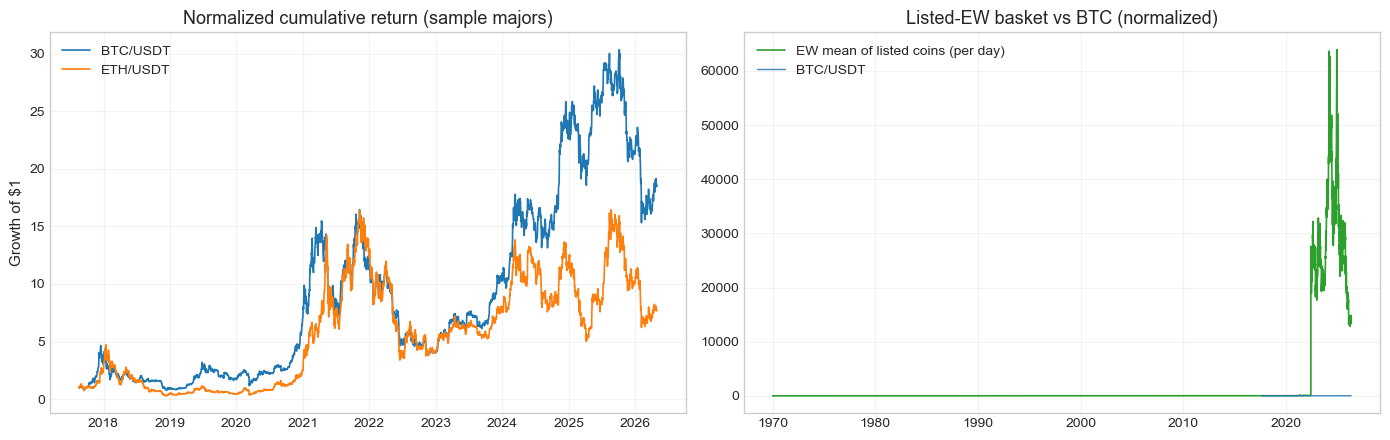


=== 5 worst EW daily returns (listed-EW basket) ===
date
2020-03-12 00:00:00+00:00   -0.4314
2021-05-19 00:00:00+00:00   -0.3301
2022-05-11 00:00:00+00:00   -0.2597
2025-10-10 00:00:00+00:00   -0.2154
2018-01-16 00:00:00+00:00   -0.2151

=== 5 best EW daily returns ===
date
2018-08-17 00:00:00+00:00     0.1817
2021-05-20 00:00:00+00:00     0.1830
2021-05-24 00:00:00+00:00     0.2419
2021-01-23 00:00:00+00:00     7.7897
2022-05-31 00:00:00+00:00   709.5904
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log_crypto.md  (Cell 4 — EDA crypto panel)


In [7]:
# =============================================================================
# CELL 4 — EDA: aligned price panel + daily returns (crypto)
# Mirrors equity Cell 4 intent: sanity-check range, scale, spread behaviour.
# Uses `closes` and `common_idx` from Cell 2 (run Cells 1–3 first).
#
# IMPORTANT (point-in-time): we do NOT drop rows where any coin is NaN.
# A NaN in panel[date, coin] means "coin not yet listed on date" - downstream
# cells (Cell 6, Cell 11) use this signal to enforce per-coin eligibility at
# the rebalance date instead of forcing every coin to exist on every date.
# =============================================================================

# Wide panel: keep NaN where a coin was not yet listed (point-in-time).
panel = closes.reindex(common_idx).astype("float64")

# Daily simple returns: NaN-aware (pre-listing returns are NaN).
rets_d = panel.pct_change()

# Drop the leading row (which is NaN for every column due to pct_change).
rets_d = rets_d.iloc[1:]

print("=== Aligned panel (levels) - point-in-time, NaN before listing ===")
print(f"  shape         : {panel.shape}")
print(f"  date range    : {panel.index[0]} -> {panel.index[-1]}  (n={len(panel)})")
print(f"  symbols       : {len(panel.columns)}")
print(f"  total NaN     : {int(panel.isnull().sum().sum())}  ({panel.isnull().sum().sum() / panel.size * 100:.1f}% of cells)")

print("\n=== Daily simple returns (point-in-time) ===")
print(f"  shape         : {rets_d.shape}")
_obs_per_coin = rets_d.notna().sum().sort_values()
print(f"  obs/coin min  : {int(_obs_per_coin.iloc[0])}  ({_obs_per_coin.index[0]})")
print(f"  obs/coin max  : {int(_obs_per_coin.iloc[-1])}  ({_obs_per_coin.index[-1]})")

# Per-symbol annualized vol (365d scaling — crypto trades every calendar day).
ann_vol = rets_d.std(ddof=1) * np.sqrt(365.0)
print("\n=== Annualized vol (daily ret × sqrt(365)) — sample ===")
print(ann_vol.sort_values(ascending=False).head(8).round(4).to_string())
print("  ...")
print(ann_vol.sort_values(ascending=True).head(5).round(4).to_string())

# Pairwise correlation sample (first 12 columns; pandas .corr() ignores NaN pairwise).
sub = rets_d.columns[:12]
corr = rets_d[sub].corr()
print(f"\n=== Return correlation (subset {list(sub)}; pairwise NaN-aware) ===")
print(corr.round(2).to_string())

# --- plots: normalized growth of a few liquid names ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for c in [MKT_SYMBOL, "ETH/USDT"]:
    if c in rets_d.columns:
        # cumprod ignoring NaN: start cumulative from first valid return
        r = rets_d[c].dropna()
        cum = (1.0 + r).cumprod()
        axes[0].plot(cum.index, cum / cum.iloc[0], label=c, lw=1.2)
axes[0].set_title("Normalized cumulative return (sample majors)")
axes[0].set_ylabel("Growth of $1")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.25)

# Cross-sectional EW basket: mean across COINS THAT ARE LISTED each day.
# (np.nanmean per row; pandas .mean(axis=1) skips NaN by default).
ew = rets_d.mean(axis=1)
cum_ew = (1.0 + ew.fillna(0.0)).cumprod()
axes[1].plot(cum_ew.index, cum_ew / cum_ew.iloc[0], color="C2", lw=1.2,
             label="EW mean of listed coins (per day)")
if MKT_SYMBOL in rets_d.columns:
    b = (1.0 + rets_d[MKT_SYMBOL].dropna()).cumprod()
    axes[1].plot(b.index, b / b.iloc[0], color="C0", lw=1.0, alpha=0.85, label=MKT_SYMBOL)
axes[1].set_title("Listed-EW basket vs BTC (normalized)")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Worst / best single days for the listed-EW basket (stress glimpse).
ew_sorted = ew.dropna().sort_values()
print("\n=== 5 worst EW daily returns (listed-EW basket) ===")
print(ew_sorted.head(5).round(4).to_string())
print("\n=== 5 best EW daily returns ===")
print(ew_sorted.tail(5).round(4).to_string())

log_state("Cell 4 — EDA crypto panel", {
    "panel_shape": list(panel.shape),
    "rets_d_shape": list(rets_d.shape),
    "panel_range": f"{panel.index[0]} -> {panel.index[-1]}",
    "ann_vol_desc": ann_vol.describe().to_dict(),
})


Market proxy : BTC/USDT  (simple daily returns, decimal)
Date range   : 1970-01-20 23:57:07.200000+00:00 -> 2026-04-30 00:00:00+00:00
Observations : 3,206
NaN count    : 28

=== Daily market return distribution ===
  Mean            : 0.1546%
  Std             : 3.5546%
  Skewness        : -0.2303
  Excess kurtosis : 8.5413

  # positive days : 1,628 (51.2%)
  # negative days : 1,550 (48.8%)

=== Squared return asymmetry (RPM motivation) ===
  E[r^2 | r>=0]   : 13.1981 x10^-4
  E[r^2 | r<0]    : 12.0843 x10^-4
  Ratio neg/pos : 0.9156
  => negative days contribute 47.8% of total squared returns

=== Rolling RPM preview (126 calendar days × SCALE=0.241402) ===
  RPM+ mean : 0.020487
  RPM- mean : 0.017842
  Ratio neg/pos mean : 0.9352



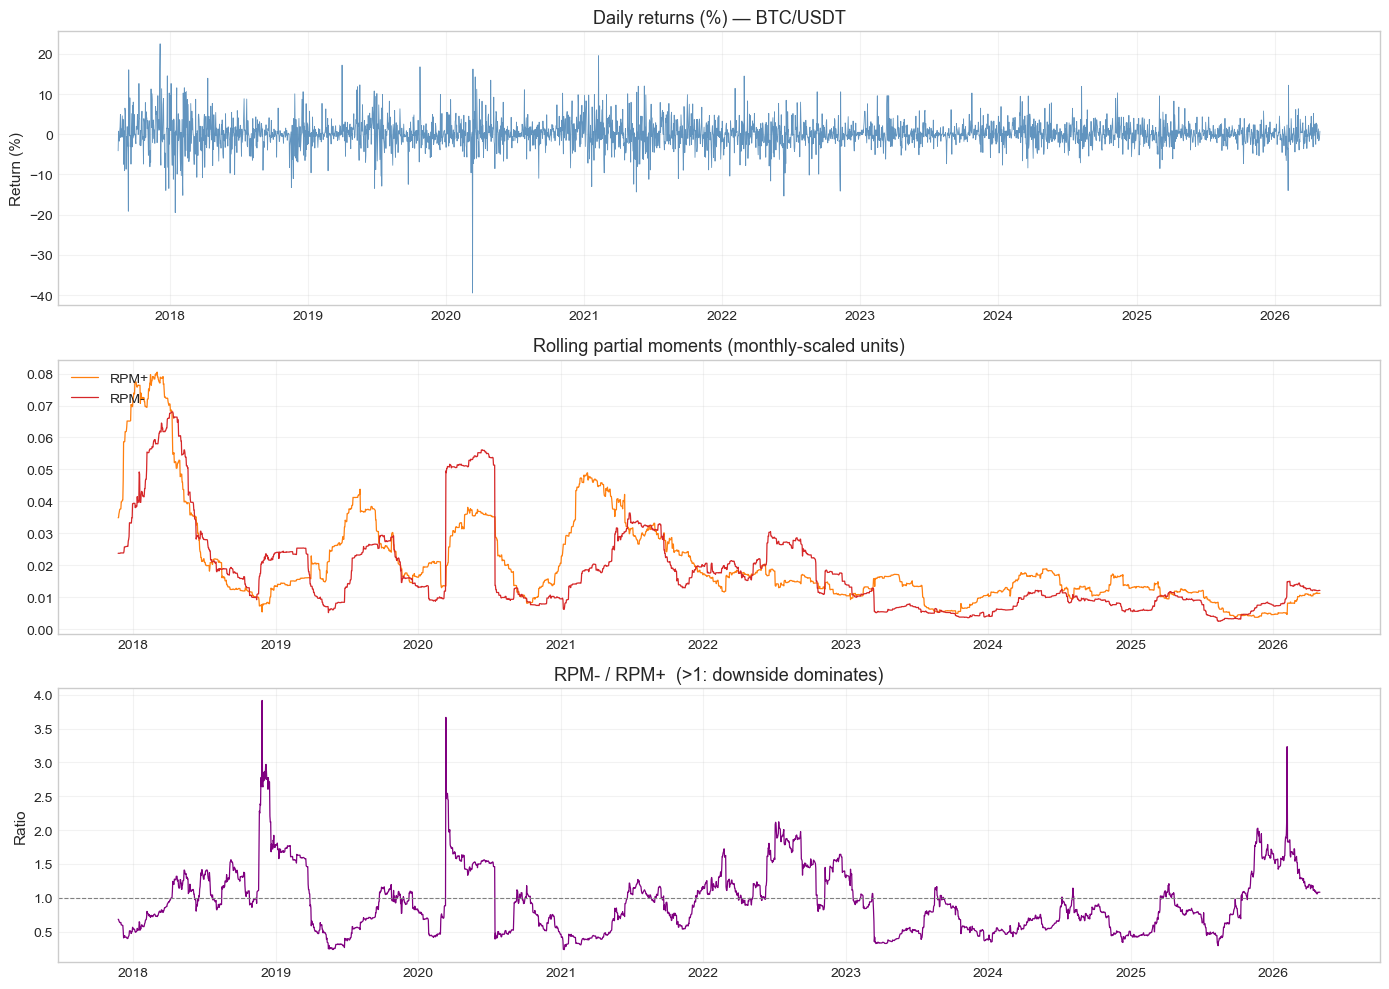

[log] state written -> C:\Users\User\Documents\pmm\cell_state_log_crypto.md  (Cell 5 — EDA daily market (BTC))


In [8]:
# =============================================================================
# CELL 5 — EDA: daily "market" returns (BTC) for RPM motivation
# Equity notebook uses FF daily Mkt-RF+RF. Here: simple daily return on
# MKT_SYMBOL from the same `rets_d` grid as Cell 4 (aligned universe dates).
# Rolling RPM preview uses the same SCALE as Cell 1 ((365/12)/126 on a 126-
# calendar-day sum -> 12*RV = annualized variance under a 365-day crypto year).
# =============================================================================

if "rets_d" not in globals():
    raise RuntimeError("rets_d not in globals - run Cell 4 first.")
if MKT_SYMBOL not in rets_d.columns:
    raise RuntimeError(
        f"MKT_SYMBOL={MKT_SYMBOL!r} not in rets_d.columns ({len(rets_d.columns)} cols). "
        f"Most likely: Cell 2.5 didn't successfully download BTCUSDT (the run was "
        f"interrupted or hit a network error). Fix: re-run Cell 2.5 (the parquet "
        f"cache will resume from where it left off), then re-run Cell 4, then this "
        f"cell. First 10 columns currently in rets_d: {list(rets_d.columns[:10])}"
    )

mkt_daily = rets_d[MKT_SYMBOL].astype("float64").copy()
mkt_daily.name = "mkt_daily"

print(f"Market proxy : {MKT_SYMBOL}  (simple daily returns, decimal)")
print(f"Date range   : {mkt_daily.index[0]} -> {mkt_daily.index[-1]}")
print(f"Observations : {len(mkt_daily):,}")
print(f"NaN count    : {int(mkt_daily.isnull().sum())}")
print()

# Use only non-NaN observations for stats
_md = mkt_daily.dropna()
pos_ret = _md[_md >= 0]
neg_ret = _md[_md < 0]

print("=== Daily market return distribution ===")
print(f"  Mean            : {_md.mean() * 100:.4f}%")
print(f"  Std             : {_md.std(ddof=1) * 100:.4f}%")
print(f"  Skewness        : {float(skew(_md)):.4f}")
print(f"  Excess kurtosis : {float(kurtosis(_md, fisher=True)):.4f}")
print()
print(f"  # positive days : {len(pos_ret):,} ({len(pos_ret) / len(_md) * 100:.1f}%)")
print(f"  # negative days : {len(neg_ret):,} ({len(neg_ret) / len(_md) * 100:.1f}%)")
print()

mean_sq_pos = float(np.mean(pos_ret.values ** 2)) if len(pos_ret) else float("nan")
mean_sq_neg = float(np.mean(neg_ret.values ** 2)) if len(neg_ret) else float("nan")
print("=== Squared return asymmetry (RPM motivation) ===")
print(f"  E[r^2 | r>=0]   : {mean_sq_pos * 1e4:.4f} x10^-4")
print(f"  E[r^2 | r<0]    : {mean_sq_neg * 1e4:.4f} x10^-4")
if mean_sq_pos and mean_sq_pos > 0:
    print(f"  Ratio neg/pos : {mean_sq_neg / mean_sq_pos:.4f}")
    print(
        f"  => negative days contribute "
        f"{mean_sq_neg / (mean_sq_pos + mean_sq_neg) * 100:.1f}% of total squared returns"
    )
print()

r2 = mkt_daily ** 2
r2_pos = r2.where(mkt_daily >= 0, 0.0)
r2_neg = r2.where(mkt_daily < 0, 0.0)
rpm_pos_roll = r2_pos.rolling(RPM_WINDOW, min_periods=RPM_WINDOW).sum() * SCALE
rpm_neg_roll = r2_neg.rolling(RPM_WINDOW, min_periods=RPM_WINDOW).sum() * SCALE
ratio_roll = rpm_neg_roll / rpm_pos_roll.replace(0, np.nan)

print(f"=== Rolling RPM preview ({RPM_WINDOW} calendar days × SCALE={SCALE:.6f}) ===")
print(f"  RPM+ mean : {rpm_pos_roll.mean():.6f}")
print(f"  RPM- mean : {rpm_neg_roll.mean():.6f}")
print(f"  Ratio neg/pos mean : {ratio_roll.mean():.4f}")
print()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
axes[0].plot(mkt_daily.index, mkt_daily.values * 100, color="steelblue", lw=0.6, alpha=0.85)
axes[0].set_title(f"Daily returns (%) — {MKT_SYMBOL}")
axes[0].set_ylabel("Return (%)")
axes[0].grid(alpha=0.25)

axes[1].plot(rpm_pos_roll.index, rpm_pos_roll, label="RPM+", color="C1", lw=0.9)
axes[1].plot(rpm_neg_roll.index, rpm_neg_roll, label="RPM-", color="C3", lw=0.9)
axes[1].set_title("Rolling partial moments (monthly-scaled units)")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.25)

axes[2].plot(ratio_roll.index, ratio_roll, color="purple", lw=0.9)
axes[2].axhline(1.0, color="gray", ls="--", lw=0.8)
axes[2].set_title("RPM- / RPM+  (>1: downside dominates)")
axes[2].set_ylabel("Ratio")
axes[2].grid(alpha=0.25)
plt.tight_layout()
plt.show()

log_state("Cell 5 — EDA daily market (BTC)", {
    "mkt_daily": mkt_daily,
    "rpm_pos_roll": rpm_pos_roll.dropna(),
    "rpm_neg_roll": rpm_neg_roll.dropna(),
    "ratio_roll": ratio_roll.dropna(),
})


In [9]:
# =============================================================================
# CELL 6 — WML portfolio construction (crypto cross-section, POINT-IN-TIME)
# Equity notebook: FF mom Hi/Lo PRIOR deciles (%). Here: equal-weight top/bottom
# decile (~10%) of the *eligible* universe at each hold date T, using prior
# 11-month cumulative return (months t-12 ... t-2, skip t-1). Returns are decimal.
# rf = 0 (no crypto risk-free). mkt_excess = monthly BTC return.
# Index: pandas Period[M] (month-end convention), aligned for downstream RPM.
#
# Point-in-time eligibility at month T (the no-look-ahead rule):
#   (a) Coin must be in PIT_UNIVERSE[T] (top-PIT_UNIVERSE_SIZE by trailing-30d
#       $vol AS OF T - computed in Cell 2.5 from Binance Vision history). This
#       eliminates the "we picked coins because they're liquid today" bias.
#   (b) Coin must have a non-NaN monthly return at every formation period
#       T-12..T-2 (i.e. it was listed at or before T-12 months and has unbroken
#       data since) AND a non-NaN hold return at T.
# k_dec (decile width) is computed from |(a) ∩ (b)| per month - it varies as new
# coins age in / drop out of the top-N rank. No fixed-universe survivor bias.
# =============================================================================

if "rets_d" not in globals():
    raise RuntimeError("Run Cell 4 first (need rets_d).")
if "log_state" not in globals():
    raise RuntimeError("Run Cell 3 first (need log_state).")
if "PIT_UNIVERSE" not in globals():
    raise RuntimeError("Run Cell 2.5 first (need PIT_UNIVERSE for point-in-time eligibility).")

# --- monthly simple compound returns from daily (UTC month-end buckets) ---
# Resample with min_count=1 so months entirely NaN -> NaN (not 0).
_monthly = rets_d.resample("ME").apply(
    lambda x: (1.0 + x).prod(min_count=1, axis=0) - 1.0
)
_monthly.index = _monthly.index.to_period("M")
monthly_rets = _monthly.sort_index()

if monthly_rets.shape[1] < 10:
    raise ValueError("Need at least 10 names for decile-style WML.")

months = monthly_rets.index
r_win_list, r_los_list, wml_list, mkt_list = [], [], [], []
idx_list, eligible_count_list, k_dec_list, pit_size_list = [], [], [], []

for T in months:
    form_periods = pd.period_range(T - FORM_START, T - FORM_END, freq="M")
    if not form_periods.isin(monthly_rets.index).all():
        continue
    if T not in monthly_rets.index:
        continue
    # PIT universe at T (top-N by trailing-30d $vol as of month-end T).
    pit_syms = PIT_UNIVERSE.get(T, [])
    if len(pit_syms) < 10:
        continue
    pit_syms_in_panel = [s for s in pit_syms if s in monthly_rets.columns]
    if len(pit_syms_in_panel) < 10:
        continue
    form_block = monthly_rets.reindex(form_periods)[pit_syms_in_panel]
    r_hold = monthly_rets.loc[T, pit_syms_in_panel]
    # Per-coin age check: full formation window + valid hold return.
    elig_mask = form_block.notna().all() & r_hold.notna()
    eligible = elig_mask[elig_mask].index.tolist()
    if len(eligible) < 10:
        continue
    fb = form_block[eligible]
    rh = r_hold[eligible]
    mom = (1.0 + fb).prod(axis=0) - 1.0
    if mom.isnull().any():
        continue
    k_dec = max(1, len(eligible) // 10)
    win_syms = mom.nlargest(k_dec).index
    los_syms = mom.nsmallest(k_dec).index
    r_win_m = float(rh[win_syms].mean())
    r_los_m = float(rh[los_syms].mean())
    r_win_list.append(r_win_m)
    r_los_list.append(r_los_m)
    wml_list.append(r_win_m - r_los_m)
    idx_list.append(T)
    eligible_count_list.append(len(eligible))
    k_dec_list.append(k_dec)
    pit_size_list.append(len(pit_syms_in_panel))
    if MKT_SYMBOL in rh.index and pd.notna(rh[MKT_SYMBOL]):
        mkt_list.append(float(rh[MKT_SYMBOL]))
    else:
        mkt_list.append(float("nan"))

if len(idx_list) == 0:
    raise RuntimeError(
        "No valid WML months (need >= 10 coins in PIT universe AND past full formation). "
        "Check Cell 2.5 PIT_UNIVERSE coverage or relax PIT_UNIVERSE_SIZE / FORM_START."
    )

idx = pd.Index(idx_list, dtype="period[M]")
r_win = pd.Series(r_win_list, index=idx, name="r_win")
r_los = pd.Series(r_los_list, index=idx, name="r_los")
wml   = pd.Series(wml_list,   index=idx, name="wml")
mkt_m = pd.Series(mkt_list,   index=idx, name="mkt_m")
rf_monthly = pd.Series(0.0, index=idx, name="rf")
mkt_excess = mkt_m - rf_monthly
mkt_excess.name = "mkt_excess"
pit_size_per_month  = pd.Series(pit_size_list,        index=idx, name="pit_size")
eligible_per_month  = pd.Series(eligible_count_list,  index=idx, name="n_eligible")
k_dec_per_month     = pd.Series(k_dec_list,           index=idx, name="k_dec")

assert (wml.index == r_win.index).all()
assert (wml.index == r_los.index).all()

returns_df = pd.DataFrame(
    {
        "r_win": r_win,
        "r_los": r_los,
        "wml": wml,
        "rf": rf_monthly,
        "mkt_excess": mkt_excess,
    }
)

print("=== WML construction (crypto, point-in-time over PIT_UNIVERSE) ===")
print(f"  super-universe     : {monthly_rets.shape[1]} coins (Cell 2.5)")
print(f"  formation months   : t-{FORM_START} ... t-{FORM_END} (skip t-1 vs month-end ranks)")
print(f"  monthly rows       : {len(monthly_rets)}  from {monthly_rets.index[0]} -> {monthly_rets.index[-1]}")
print(f"  valid WML months   : {len(returns_df)}  from {returns_df.index[0]} -> {returns_df.index[-1]}")
print(f"  NaNs in returns_df : {int(returns_df.isnull().sum().sum())}")
print()
print("  PIT universe size per month (top-N by trailing $vol):")
print(f"    min={int(pit_size_per_month.min())}  max={int(pit_size_per_month.max())}  "
      f"mean={pit_size_per_month.mean():.1f}")
print("  Eligible after age filter (PIT ∩ full formation history):")
print(f"    min={int(eligible_per_month.min())}  max={int(eligible_per_month.max())}  "
      f"mean={eligible_per_month.mean():.1f}")
print(f"  k_dec per month: min={int(k_dec_per_month.min())} max={int(k_dec_per_month.max())}")
print()

ann_ret = float(wml.mean() * 12 * 100)
ann_vol = float(wml.std(ddof=1) * np.sqrt(12) * 100)
ann_sr  = float((wml.mean() * 12) / (wml.std(ddof=1) * np.sqrt(12))) if wml.std(ddof=1) > 0 else float("nan")
eq  = (1.0 + wml).cumprod()
mdd = float(((eq / eq.cummax()) - 1.0).min() * 100)

print("=== WML summary (PIT, not comparable to paper Table 1) ===")
print(f"  Ann. return (approx): {ann_ret:.2f}%")
print(f"  Ann. vol              : {ann_vol:.2f}%")
print(f"  Ann. Sharpe           : {ann_sr:.4f}")
print(f"  Skewness              : {float(skew(wml.values)):.4f}")
print(f"  Excess kurtosis       : {float(kurtosis(wml.values, fisher=True)):.4f}")
print(f"  Max drawdown          : {mdd:.2f}%")
print()

print("=== returns_df (head + tail) ===")
print(returns_df.head(5))
print("...")
print(returns_df.tail(5))
print(f"\nShape: {returns_df.shape}")

log_state("Cell 6 — WML construction (crypto, PIT)", {
    "returns_df": returns_df,
    "r_win": r_win,
    "r_los": r_los,
    "wml": wml,
    "pit_size_per_month": pit_size_per_month,
    "eligible_per_month": eligible_per_month,
    "monthly_rets": monthly_rets,
})


=== WML construction (crypto, point-in-time over PIT_UNIVERSE) ===
  super-universe     : 414 coins (Cell 2.5)
  formation months   : t-12 ... t-2 (skip t-1 vs month-end ranks)
  monthly rows       : 676  from 1970-01 -> 2026-04
  valid WML months   : 83  from 2019-06 -> 2026-04
  NaNs in returns_df : 0

  PIT universe size per month (top-N by trailing $vol):
    min=46  max=50  mean=50.0
  Eligible after age filter (PIT ∩ full formation history):
    min=15  max=43  mean=33.8
  k_dec per month: min=1 max=4

=== WML summary (PIT, not comparable to paper Table 1) ===
  Ann. return (approx): -194.66%
  Ann. vol              : 155.00%
  Ann. Sharpe           : -1.2558
  Skewness              : -0.6447
  Excess kurtosis       : 1.8923
  Max drawdown          : -176.69%

=== returns_df (head + tail) ===
          r_win   r_los     wml     rf  mkt_excess
2019-06 -0.0235 -0.0591  0.0357 0.0000      0.2687
2019-07 -0.1359 -0.1275 -0.0084 0.0000     -0.0713
2019-08 -0.2411 -0.2287 -0.0124 0.000

In [10]:
# =============================================================================
# CELL 7 — RPM+/RPM- (Numba), aligned to `returns_df`
#
# Replicates: `pmm_strategy.ipynb` Cell 7 (paper eq. 4-5; same window + numba
# kernel). SCALE differs: equity uses 21/126 (252-day year); crypto uses
# (365/12)/126 from Cell 1 so 12*RV = annualized variance under a 365-day year.
# Difference: daily returns are BTC/USDT close-to-close from `ohlcv_daily`
# (full downloaded history), not (Mkt-RF + RF) from Kenneth French.
# Month-end positions are the last daily bar in each calendar month (UTC),
# matched to `returns_df.index` (Period[M]) from Cell 6.
# =============================================================================

@jit(nopython=True, cache=True)
def _compute_rpm(r_daily, month_end_pos, window, scale):
    """RPM+ / RPM- at each month-end index in `r_daily` (same logic as equity notebook)."""
    n = len(month_end_pos)
    rpm_pos = np.empty(n, dtype=np.float64)
    rpm_neg = np.empty(n, dtype=np.float64)
    for i in range(n):
        pos = month_end_pos[i]
        start = pos - window + 1
        if start < 0:
            rpm_pos[i] = np.nan
            rpm_neg[i] = np.nan
            continue
        s_pos = 0.0
        s_neg = 0.0
        for j in range(start, pos + 1):
            r = r_daily[j]
            r2 = r * r
            if r >= 0.0:
                s_pos += r2
            else:
                s_neg += r2
        rpm_pos[i] = scale * s_pos
        rpm_neg[i] = scale * s_neg
    return rpm_pos, rpm_neg


if "returns_df" not in globals():
    raise RuntimeError("Run Cell 6 first (need returns_df).")
if "ohlcv_daily" not in globals() or MKT_SYMBOL not in ohlcv_daily:
    raise RuntimeError("Run Cell 2 first (need ohlcv_daily and MKT_SYMBOL).")
if "log_state" not in globals():
    raise RuntimeError("Run Cell 3 first (need log_state).")

# --- daily market returns (decimal): full BTC series for RPM lookback coverage ---
_btc = ohlcv_daily[MKT_SYMBOL]["close"].sort_index()
mkt_d = _btc.pct_change().dropna()
mkt_d = mkt_d.astype("float64")
r_daily_arr = mkt_d.values.astype(np.float64)
daily_dates = mkt_d.index

# Compare on naive dates if index is tz-aware (month bounds are naive Timestamps)
if getattr(daily_dates, "tz", None) is not None:
    daily_cmp = daily_dates.tz_convert("UTC").tz_localize(None)
else:
    daily_cmp = daily_dates

month_periods = returns_df.index
month_end_positions = np.empty(len(month_periods), dtype=np.int64)

for i, period in enumerate(month_periods):
    month_start = pd.Timestamp(period.start_time)
    month_end = pd.Timestamp(period.end_time)
    mask = (daily_cmp >= month_start) & (daily_cmp <= month_end)
    idx = np.where(mask)[0]
    if len(idx) == 0:
        month_end_positions[i] = -1
    else:
        month_end_positions[i] = int(idx[-1])

missing = int((month_end_positions == -1).sum())
print(f"Month-end position mapping: {len(month_periods)} months, {missing} missing")

if missing:
    raise RuntimeError("Some returns_df months have no BTC daily bar; check calendars.")

print("Compiling numba JIT (first call)...")
t0 = time.time()
_ = _compute_rpm(r_daily_arr[: min(200, len(r_daily_arr))], month_end_positions[: min(5, len(month_periods))], RPM_WINDOW, SCALE)
print(f"  JIT compile done in {time.time() - t0:.2f}s")

print("Running full RPM computation...")
t0 = time.time()
rpm_pos_arr, rpm_neg_arr = _compute_rpm(r_daily_arr, month_end_positions, RPM_WINDOW, SCALE)
elapsed = time.time() - t0
print(f"  Done in {elapsed * 1000:.1f} ms for {len(month_periods)} months")

rpm_pos = pd.Series(rpm_pos_arr, index=returns_df.index, name="RPM_pos")
rpm_neg = pd.Series(rpm_neg_arr, index=returns_df.index, name="RPM_neg")
rv = rpm_pos + rpm_neg

nan_count = int(rpm_pos.isnull().sum())
first_valid = rpm_pos.first_valid_index()
print(f"\nNaN months (insufficient 126-day history): {nan_count}")
print(f"First valid RPM month: {first_valid}")
print()

ratio = rpm_neg / rpm_pos.replace(0, np.nan)
print("=== RPM stats (crypto BTC, monthly grid from returns_df) ===")
print(f"  RPM+ mean : {rpm_pos.mean():.6f}")
print(f"  RPM- mean : {rpm_neg.mean():.6f}")
print(f"  RV   mean : {rv.mean():.6f}")
print(f"  RPM-/RPM+ mean ratio : {ratio.mean():.4f}")
print()

print("=== RPM in sample (all months on returns_df) ===")
_disp = pd.DataFrame({"RPM+": rpm_pos, "RPM-": rpm_neg, "ratio": ratio})
print(_disp.to_string())

log_state("Cell 7 — RPM computation (crypto)", {
    "rpm_pos": rpm_pos,
    "rpm_neg": rpm_neg,
    "rv": rv,
    "ratio": ratio.dropna(),
})


Month-end position mapping: 83 months, 0 missing
Compiling numba JIT (first call)...
  JIT compile done in 0.27s
Running full RPM computation...
  Done in 0.1 ms for 83 months

NaN months (insufficient 126-day history): 0
First valid RPM month: 2019-06

=== RPM stats (crypto BTC, monthly grid from returns_df) ===
  RPM+ mean : 0.017742
  RPM- mean : 0.015088
  RV   mean : 0.032831
  RPM-/RPM+ mean ratio : 0.8835

=== RPM in sample (all months on returns_df) ===
          RPM+   RPM-  ratio
2019-06 0.0337 0.0130 0.3866
2019-07 0.0418 0.0232 0.5550
2019-08 0.0373 0.0264 0.7076
2019-09 0.0256 0.0294 1.1486
2019-10 0.0264 0.0248 0.9420
2019-11 0.0176 0.0158 0.9001
2019-12 0.0163 0.0135 0.8306
2020-01 0.0207 0.0092 0.4430
2020-02 0.0132 0.0099 0.7469
2020-03 0.0308 0.0508 1.6485
2020-04 0.0358 0.0511 1.4276
2020-05 0.0363 0.0542 1.4937
2020-06 0.0356 0.0545 1.5327
2020-07 0.0228 0.0099 0.4321
2020-08 0.0179 0.0094 0.5238
2020-09 0.0102 0.0098 0.9561
2020-10 0.0100 0.0074 0.7408
2020-11 0.01

In [11]:
# =============================================================================
# CELL 8 — VM, PMM, PMMC strategy returns
#
# Replicates: `pmm_strategy.ipynb` Cell 8 (same formulas: phi_vm, phi1/phi2,
# leverage cap, one-month shift so weights at t apply to returns at t+1).
# Inputs are already crypto (`returns_df`, `rv`, `rpm_pos`, `rpm_neg` from
# Cells 6–7); `rf` is zero here so the cash term in PMM/PMMC vanishes.
# Paper Table 1 targets are US FF-sample reference only, not a benchmark.
# =============================================================================

if "returns_df" not in globals() or "rv" not in globals():
    raise RuntimeError("Run Cells 6 and 7 first (need returns_df, rv, rpm_pos, rpm_neg).")
if "log_state" not in globals():
    raise RuntimeError("Run Cell 3 first (need log_state).")

rv_arr = rv.values.astype(np.float64)
rpm_pos_arr = rpm_pos.values.astype(np.float64)
rpm_neg_arr = rpm_neg.values.astype(np.float64)

sigma_tar = SIGMA_TAR

phi_vm = ne.evaluate(
    "sigma_tar / sqrt(12 * rv_arr)",
    local_dict={"sigma_tar": sigma_tar, "rv_arr": rv_arr},
)

phi1 = ne.evaluate(
    "2*sigma_tar / sqrt(12 * rv_arr) * rpm_pos_arr / rv_arr",
    local_dict={
        "sigma_tar": sigma_tar,
        "rv_arr": rv_arr,
        "rpm_pos_arr": rpm_pos_arr,
    },
)
phi2 = ne.evaluate(
    "2*sigma_tar / sqrt(12 * rv_arr) * rpm_neg_arr / rv_arr",
    local_dict={
        "sigma_tar": sigma_tar,
        "rv_arr": rv_arr,
        "rpm_neg_arr": rpm_neg_arr,
    },
)

leverage_pmm = phi1 + phi2

phi1_c = phi1.copy()
phi2_c = phi2.copy()
cap_mask = leverage_pmm > MAX_LEV
phi1_c[cap_mask] = ne.evaluate(
    "2.0 * rpm_pos_arr / rv_arr",
    local_dict={"rpm_pos_arr": rpm_pos_arr[cap_mask], "rv_arr": rv_arr[cap_mask]},
)
phi2_c[cap_mask] = ne.evaluate(
    "2.0 * rpm_neg_arr / rv_arr",
    local_dict={"rpm_neg_arr": rpm_neg_arr[cap_mask], "rv_arr": rv_arr[cap_mask]},
)

print("=== Weight diagnostics ===")
print(
    f"  phi_vm   : mean={phi_vm.mean():.4f}  std={phi_vm.std():.4f}  "
    f"min={phi_vm.min():.4f}  max={phi_vm.max():.4f}"
)
print(
    f"  phi1 (L) : mean={phi1.mean():.4f}  std={phi1.std():.4f}  "
    f"min={phi1.min():.4f}  max={phi1.max():.4f}  (paper FF sample: mean~1.05)"
)
print(
    f"  phi2 (S) : mean={phi2.mean():.4f}  std={phi2.std():.4f}  "
    f"min={phi2.min():.4f}  max={phi2.max():.4f}  (paper FF sample: mean~0.93)"
)
print(f"  PMM leverage (phi1+phi2): mean={leverage_pmm.mean():.4f}")
print(
    f"  Months where phi1+phi2 > MAX_LEV ({MAX_LEV}): {int(cap_mask.sum())} "
    f"({cap_mask.mean() * 100:.1f}% of RPM months)"
)
print()

r_win_arr = returns_df["r_win"].values.astype(np.float64)
r_los_arr = returns_df["r_los"].values.astype(np.float64)
wml_arr = returns_df["wml"].values.astype(np.float64)
rf_arr = returns_df["rf"].values.astype(np.float64)

idx = returns_df.index

r_vm = phi_vm[:-1] * wml_arr[1:]
r_pmm = (
    phi1[:-1] * r_win_arr[1:]
    - phi2[:-1] * r_los_arr[1:]
    + (phi2[:-1] - phi1[:-1]) * rf_arr[1:]
)
r_pmmc = (
    phi1_c[:-1] * r_win_arr[1:]
    - phi2_c[:-1] * r_los_arr[1:]
    + (phi2_c[:-1] - phi1_c[:-1]) * rf_arr[1:]
)

r_wml = wml_arr[1:]
strat_idx = idx[1:]

strategies = pd.DataFrame(
    {"WML": r_wml, "VM": r_vm, "PMM": r_pmm, "PMMC": r_pmmc},
    index=strat_idx,
)

print("=== Strategy returns DataFrame ===")
print(f"  Shape : {strategies.shape}")
print(f"  Index : {strategies.index[0]} -> {strategies.index[-1]}")
print(f"  NaNs  : {strategies.isnull().sum().to_dict()}")
print()
print(strategies)
print()

_targets = {"WML": (14.98, 0.52), "VM": (18.19, 1.02), "PMM": (20.44, 1.23), "PMMC": (18.71, 1.11)}
_n = len(strategies)
if _n < 12:
    print(f"=== Annualized stats (only {_n} post-shift months; interpret cautiously) ===")
else:
    print("=== Annualized stats (paper Table 1 = US FF reference only) ===")

for col in strategies.columns:
    s = strategies[col]
    ar = s.mean() * 12 * 100
    denom = s.std() * np.sqrt(12)
    sr = (s.mean() * 12) / denom if denom > 0 else float("nan")
    mdd = (((1 + s).cumprod() / (1 + s).cumprod().cummax()) - 1).min() * 100
    t_ar, t_sr = _targets[col]
    print(
        f"  {col:5s}  ann.ret={ar:6.2f}%  SR={sr:.4f}  MDD={mdd:.2f}%"
        f"   (paper FF: ret={t_ar:.2f}%  SR={t_sr:.2f})"
    )

log_state("Cell 8 — Strategy returns (crypto)", {
    "strategies": strategies,
    "phi1": pd.Series(phi1, index=idx, name="phi1"),
    "phi2": pd.Series(phi2, index=idx, name="phi2"),
    "phi_vm": pd.Series(phi_vm, index=idx, name="phi_vm"),
})


=== Weight diagnostics ===
  phi_vm   : mean=0.2173  std=0.0636  min=0.1152  max=0.4043
  phi1 (L) : mean=0.2422  std=0.0871  min=0.0911  max=0.4566  (paper FF sample: mean~1.05)
  phi2 (S) : mean=0.1925  std=0.0717  min=0.0779  max=0.4162  (paper FF sample: mean~0.93)
  PMM leverage (phi1+phi2): mean=0.4346
  Months where phi1+phi2 > MAX_LEV (2.0): 0 (0.0% of RPM months)

=== Strategy returns DataFrame ===
  Shape : (82, 4)
  Index : 2019-07 -> 2026-04
  NaNs  : {'WML': 0, 'VM': 0, 'PMM': 0, 'PMMC': 0}

            WML      VM     PMM    PMMC
2019-07 -0.0084 -0.0014 -0.0200 -0.0200
2019-08 -0.0124 -0.0017 -0.0199 -0.0199
2019-09 -0.0631 -0.0087 -0.0188 -0.0188
2019-10  0.2040  0.0301  0.0270  0.0270
2019-11 -0.0551 -0.0084 -0.0101 -0.0101
...         ...     ...     ...     ...
2025-12  0.0027  0.0009 -0.0092 -0.0092
2026-01 -0.4390 -0.1382 -0.1605 -0.1605
2026-02 -0.0092 -0.0027  0.0112  0.0112
2026-03 -0.1557 -0.0357 -0.0443 -0.0443
2026-04 -0.4724 -0.1063 -0.1191 -0.1191

[82 rows 

In [12]:
# =============================================================================
# CELL 9 — Performance table (Table 1 style)
#
# Replicates: `pmm_strategy.ipynb` Cell 9 (same metrics: ann. return, t-stat,
# Sharpe, adapted Sortino, IR vs WML, MDD, skew, excess kurtosis, Jarque-Bera).
# Crypto: one table over `strategies` from Cell 8 (actual calendar range).
# The post-1963 split is US-sample specific and omitted here. Paper numbers
# below remain FF reference only, not a target for spot crypto.
# =============================================================================

from scipy.stats import t as t_dist

if "strategies" not in globals():
    raise RuntimeError("Run Cell 8 first (need strategies).")
if "log_state" not in globals():
    raise RuntimeError("Run Cell 3 first (need log_state).")

_n = len(strategies)
if _n < 2:
    raise RuntimeError(
        "Table 9 needs at least 2 post-shift monthly returns; extend history or re-run pipeline."
    )


def _perf(s, benchmark=None):
    """Performance metrics for a monthly return series s (decimal)."""
    n = len(s)
    mu_m = s.mean()
    std_m = s.std(ddof=1)
    ann_ret = mu_m * 12 * 100
    ann_vol = std_m * np.sqrt(12) * 100
    ann_sr = (mu_m * 12) / (std_m * np.sqrt(12)) if std_m > 0 else float("nan")
    tstat = mu_m / (std_m / np.sqrt(n)) if std_m > 0 else float("nan")
    pval = 2 * (1 - t_dist.cdf(abs(tstat), df=n - 1)) if std_m > 0 else float("nan")
    neg = s[s < 0]
    semi_m = np.sqrt((neg ** 2).mean()) if len(neg) > 0 else float("nan")
    sortino = (mu_m * 12) / (semi_m * np.sqrt(12)) if semi_m and semi_m > 0 else float("nan")
    if benchmark is not None:
        active = s - benchmark
        te = active.std(ddof=1)
        ir = (active.mean() * 12) / (te * np.sqrt(12)) if te and te > 0 else float("nan")
    else:
        ir = float("nan")
    cumret = (1 + s).cumprod()
    mdd = ((cumret / cumret.cummax()) - 1).min() * 100
    sk = float(stats.skew(s))
    ku = float(stats.kurtosis(s, fisher=True))
    jb_stat, jb_p = jarque_bera(s)
    return {
        "ann_ret": ann_ret,
        "tstat": tstat,
        "pval": pval,
        "ann_vol": ann_vol,
        "ann_sr": ann_sr,
        "sortino": sortino,
        "ir": ir,
        "mdd": mdd,
        "skew": sk,
        "kurt": ku,
        "jb_stat": jb_stat,
        "jb_p": jb_p,
    }


def sig_stars(pval):
    if pval != pval:  # NaN
        return ""
    if pval < 0.01:
        return "***"
    if pval < 0.05:
        return "**"
    if pval < 0.10:
        return "*"
    return ""


def _print_table(strats_df, label):
    wml_s = strats_df["WML"]
    print(f"\n{'=' * 90}")
    print(f"  {label}")
    print(f"{'=' * 90}")
    hdr = f"  {'Strategy':<8}  {'Ann.Ret%':>8}  {'SR':>6}  {'Sortino':>8}  "
    hdr += f"{'IR':>6}  {'MDD%':>7}  {'Skew':>7}  {'Kurt':>7}  {'JB stat':>10}"
    print(hdr)
    print(f"  {'-' * 86}")
    for col in strats_df.columns:
        m = _perf(strats_df[col], benchmark=(wml_s if col != "WML" else None))
        stars = sig_stars(m["pval"])
        print(
            f"  {col:<8}  {m['ann_ret']:>7.2f}{stars:<3}  "
            f"{m['ann_sr']:>6.4f}  "
            f"{m['sortino']:>8.4f}  "
            f"{m['ir']:>6.4f}  "
            f"{m['mdd']:>7.2f}  "
            f"{m['skew']:>7.4f}  "
            f"{m['kurt']:>7.4f}  "
            f"{m['jb_stat']:>10.2f}({m['jb_p']:.3f})"
        )
    print(f"{'=' * 90}")
    print()


if _n < 12:
    print(
        f"=== Note: only {_n} monthly observations after the weight shift; "
        "t-stats / JB / Sharpe are very noisy. ===\n"
    )

_label = f"Crypto sample: {strategies.index[0]} to {strategies.index[-1]}  ({_n} months)"
print("=== Performance table (crypto, post-shift `strategies`) ===")
_print_table(strategies, _label)

print("=== Paper Table 1 reference (US FF momentum deciles, full sample) ===")
print(
    "  WML   ann.ret=14.98***  SR=0.5200  Sortino=0.16  IR=   n/a  MDD=-95.45  Skew=-2.33  Kurt=17.48  JB=10414"
)
print(
    "  VM    ann.ret=18.19***  SR=1.0200  Sortino=0.58  IR= 0.800  MDD=-34.25  Skew=-0.23  Kurt= 2.06  JB=53.12"
)
print(
    "  PMM   ann.ret=20.44***  SR=1.2300  Sortino=0.82  IR= 0.910  MDD=-33.90  Skew= 0.03  Kurt= 2.72  JB=83.45"
)
print(
    "  PMMC  ann.ret=18.71***  SR=1.1100  Sortino=0.73  IR= 0.860  MDD=-26.11  Skew=-0.10  Kurt= 2.63  JB=49.49"
)

log_state("Cell 9 — Performance table (crypto)", {"strategies": strategies})


=== Performance table (crypto, post-shift `strategies`) ===

  Crypto sample: 2019-07 to 2026-04  (82 months)
  Strategy  Ann.Ret%      SR   Sortino      IR     MDD%     Skew     Kurt     JB stat
  --------------------------------------------------------------------------------------
  WML       -197.55***  -1.2682   -1.0628     nan  -176.69  -0.6280   1.8426       16.99(0.000)
  VM         -41.37***  -1.2268   -1.0314  1.2498   -97.02  -0.7346   1.7706       18.09(0.000)
  PMM        -28.85**   -0.7968   -0.7708  1.3453   -92.83  -0.0289   1.4786        7.48(0.024)
  PMMC       -28.85**   -0.7968   -0.7708  1.3453   -92.83  -0.0289   1.4786        7.48(0.024)

=== Paper Table 1 reference (US FF momentum deciles, full sample) ===
  WML   ann.ret=14.98***  SR=0.5200  Sortino=0.16  IR=   n/a  MDD=-95.45  Skew=-2.33  Kurt=17.48  JB=10414
  VM    ann.ret=18.19***  SR=1.0200  Sortino=0.58  IR= 0.800  MDD=-34.25  Skew=-0.23  Kurt= 2.06  JB=53.12
  PMM   ann.ret=20.44***  SR=1.2300  Sortino=0

In [13]:
# =============================================================================
# CELL 10 — Backtest engine: imports, constants, helpers
# Stage 4 prep: Engine API + crypto annualization (ANN_CRYPTO=365).
# Skill: skills/05-engine-single-path.md, skills/04-costs.md
# =============================================================================

from __future__ import annotations
import sys
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

BACKTEST_ROOT = Path(r"C:\Users\User\backtest_engine")
if str(BACKTEST_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKTEST_ROOT))

from backtest.data import DataPanel
from backtest.engine import Engine, MultiPathEngine
from backtest.costs import (
    Commission, Spread, MarketImpact, ShortBorrow,
    CompositeCostModel, LiquidityCap,
)
from backtest.splitters import WalkForward, CombinatorialPurgedCV
from backtest.metrics import compute_metrics
from backtest.strategy import Strategy
from backtest.risk import RiskConfig

ANN_CRYPTO = 365
INITIAL = 1_000_000.0

print(f"backtest import OK from {BACKTEST_ROOT}")
print(f"ANN_CRYPTO={ANN_CRYPTO}  INITIAL=${INITIAL:,.0f}")


def metrics_crypto(returns, equity, costs=None):
    return compute_metrics(
        returns, equity, costs=costs, ann_factor=ANN_CRYPTO, ci_level=0.95,
    )


def safe_metrics_crypto(returns, equity, costs=None):
    try:
        return metrics_crypto(returns, equity, costs=costs)
    except TypeError as exc:
        if "complex" in str(exc):
            return None
        raise


def safe_engine_summary(result, *, ann_factor=ANN_CRYPTO, rolling_window=60):
    try:
        return result.summary(ann_factor=ann_factor, rolling_window=rolling_window)
    except (ValueError, TypeError) as exc:
        msg = str(exc)
        if "insufficient data for Sharpe distribution" in msg or "complex" in msg:
            eq = result.equity_curve
            print(f"[degraded summary] {msg[:120]}")
            print(f"  final equity: ${float(eq.iloc[-1]):,.0f}")
            print(f"  total costs : ${float(result.costs.sum()):,.0f}")
            print(f"  n bars      : {len(result.returns)}")
            return None
        raise


backtest import OK from C:\Users\User\backtest_engine
ANN_CRYPTO=365  INITIAL=$1,000,000


In [14]:
# =============================================================================
# CELL 11 — crypto_panel (DataPanel) + LISTING_DATES + BT_START
# Stage 1 (engine): build panel for Engine — prices bfill+ffill, volume NaN→0.
# Skill: skills/01-data.md
# Depends on: Cell 4 (`panel`), Cell 2.5 (`ohlcv_daily`, `PIT_UNIVERSE`), Cell 10 (`DataPanel`).
# =============================================================================

if "panel" not in globals() or "ohlcv_daily" not in globals():
    raise RuntimeError("Need `panel` (Cell 4) and `ohlcv_daily` (Cell 2.5).")
if "PIT_UNIVERSE" not in globals():
    raise RuntimeError("Need PIT_UNIVERSE from Cell 2.5.")
if "DataPanel" not in globals():
    raise RuntimeError("Run Cell 10 first (need DataPanel).")

BT_START = pd.Timestamp("2020-01-01")
if getattr(panel.index, "tz", None) is not None:
    BT_START = BT_START.tz_localize(panel.index.tz)

prices_bt_raw = panel.sort_index().astype("float64").loc[BT_START:].copy()
if prices_bt_raw.index.has_duplicates:
    prices_bt_raw = prices_bt_raw[~prices_bt_raw.index.duplicated(keep="last")]

_has_data = prices_bt_raw.notna().any(axis=0)
_dropped = sorted(_has_data[~_has_data].index.tolist())
if _dropped:
    print(f"[Cell 11] dropping {len(_dropped)} coins with no data after BT_START:")
    print(f"          {_dropped[:10]}{'...' if len(_dropped) > 10 else ''}")
    prices_bt_raw = prices_bt_raw.loc[:, _has_data]

prices_bt = prices_bt_raw.bfill().ffill()
if prices_bt.isnull().any().any():
    _stillnan = prices_bt.columns[prices_bt.isnull().any()].tolist()
    raise RuntimeError(
        f"crypto_panel prices still NaN after bfill+ffill: {_stillnan[:10]}"
    )

vol_bt = (
    pd.concat(
        {s: ohlcv_daily[s]["volume"].astype("float64") for s in prices_bt.columns},
        axis=1,
    )
    .reindex(index=prices_bt.index, columns=prices_bt.columns)
    .astype("float64")
    .fillna(0.0)
)

crypto_panel = DataPanel(prices_bt, volume=vol_bt, check_outliers=False)


def _to_naive_utc(ts):
    ts = pd.Timestamp(ts)
    if ts.tzinfo is None:
        return ts
    return ts.tz_convert("UTC").tz_localize(None)


LISTING_DATES = {
    sym: _to_naive_utc(ohlcv_daily[sym].index[0])
    for sym in prices_bt.columns
    if sym in ohlcv_daily
}

_years = (crypto_panel.dates[-1] - crypto_panel.dates[0]).days / 365.25
print(
    f"\ncrypto_panel: {len(crypto_panel.dates)} bars x {len(crypto_panel.assets_all)} assets"
)
print(f"  index: {crypto_panel.dates[0]} -> {crypto_panel.dates[-1]}  ({_years:.2f} years)")
print(f"  prices NaN count: {int(prices_bt.isnull().sum().sum())}")
print(f"  volume==0 cells: {int((vol_bt == 0).sum().sum())}")
print(f"  LISTING_DATES: {len(LISTING_DATES)} assets")
print(f"  PIT_UNIVERSE: {len(PIT_UNIVERSE)} months")
print(f"  BT_START: {BT_START}")


[Cell 11] dropping 5 coins with no data after BT_START:
          ['BCC/USDT', 'BCHABC/USDT', 'BCHSV/USDT', 'USDSB/USDT', 'VEN/USDT']

crypto_panel: 2312 bars x 409 assets
  index: 2020-01-01 00:00:00+00:00 -> 2026-04-30 00:00:00+00:00  (6.33 years)
  prices NaN count: 0
  volume==0 cells: 417748
  LISTING_DATES: 409 assets
  PIT_UNIVERSE: 96 months
  BT_START: 2020-01-01 00:00:00+00:00


In [15]:
# =============================================================================
# CELL 12 — CryptoWMLStrategy (engine)
# Stage 2: monthly cross-section WML, same logic as Cell 6, PIT + listing checks.
# Skill: skills/02-strategy.md
# Depends on: Cell 1 (FORM_*), Cell 2.5 (PIT_UNIVERSE), Cell 11 (LISTING_DATES), Cell 10 (Strategy).
# =============================================================================

if "FORM_START" not in globals() or "FORM_END" not in globals():
    raise RuntimeError("Need FORM_START / FORM_END from Cell 1.")
if "LISTING_DATES" not in globals():
    raise RuntimeError("Need LISTING_DATES from Cell 11.")
if "PIT_UNIVERSE" not in globals():
    raise RuntimeError("Need PIT_UNIVERSE from Cell 2.5.")
if "Strategy" not in globals():
    raise RuntimeError("Run Cell 10 first.")


class CryptoWMLStrategy(Strategy):
    """Monthly cross-section WML; formation t-FORM_START..t-FORM_END (skip t-1)."""

    rebalance_frequency = "monthly"
    risk = RiskConfig(max_position=1.0, max_gross=2.0, max_net=None)
    LISTING_DATES = {}
    PIT_UNIVERSE_BY_PERIOD = {}

    def __init__(self, form_start=None, form_end=None):
        self.form_start = int(form_start if form_start is not None else FORM_START)
        self.form_end = int(form_end if form_end is not None else FORM_END)

    def __repr__(self):
        return f"CryptoWMLStrategy(form_start={self.form_start}, form_end={self.form_end})"

    def required_data(self):
        return {"prices": None, "volume": None}

    @staticmethod
    def _to_timestamp(t):
        return pd.Timestamp(t)

    def _clip_daily(self, t, daily):
        ts = self._to_timestamp(t)
        idx = daily.index
        if getattr(idx, "tz", None) is not None:
            ts = ts.tz_localize(idx.tz) if ts.tzinfo is None else ts.tz_convert(idx.tz)
        last_complete = ts.normalize().replace(day=1) - pd.Timedelta(days=1)
        return daily.loc[:last_complete]

    @classmethod
    def _eligible_assets(cls, all_assets, t, form_start):
        ts = pd.Timestamp(t)
        if ts.tzinfo is not None:
            ts = ts.tz_convert("UTC").tz_localize(None)
        period_t = ts.to_period("M")
        cutoff = period_t - form_start

        if cls.PIT_UNIVERSE_BY_PERIOD:
            pit_set = set(cls.PIT_UNIVERSE_BY_PERIOD.get(period_t, []))
            if not pit_set:
                pit_set = set(all_assets)
        else:
            pit_set = set(all_assets)

        if not cls.LISTING_DATES:
            return [a for a in all_assets if a in pit_set]

        eligible = []
        for a in all_assets:
            if a not in pit_set:
                continue
            ld = cls.LISTING_DATES.get(a)
            if ld is None:
                continue
            ld_ts = pd.Timestamp(ld)
            if ld_ts.tzinfo is not None:
                ld_ts = ld_ts.tz_convert("UTC").tz_localize(None)
            if ld_ts.to_period("M") <= cutoff:
                eligible.append(a)
        return eligible

    @classmethod
    def _wml_vector(cls, monthly, hold, form_start, form_end):
        assets = monthly.columns
        z = pd.Series(0.0, index=assets)
        if monthly.shape[1] < 10:
            return z
        form_periods = pd.period_range(hold - form_start, hold - form_end, freq="M")
        if not form_periods.isin(monthly.index).all():
            return z
        form_block = monthly.reindex(form_periods)
        complete = form_block.columns[form_block.notna().all()].tolist()
        if len(complete) < 10:
            return z
        form_block = form_block[complete]
        mom = (1.0 + form_block).prod(axis=0) - 1.0
        if mom.isnull().any():
            return z
        k_dec = max(1, len(complete) // 10)
        win_syms = mom.nlargest(k_dec).index
        los_syms = mom.nsmallest(k_dec).index
        w = pd.Series(0.0, index=assets)
        w.loc[win_syms] = 1.0 / k_dec
        w.loc[los_syms] = -1.0 / k_dec
        return w

    def generate_weights(self, data, t):
        z = pd.Series(0.0, index=data.assets)
        eligible = self._eligible_assets(list(data.assets), t, self.form_start)
        if len(eligible) < 10:
            return z
        px = data.prices[eligible].astype("float64")
        if len(px) < 40:
            return z
        daily = px.pct_change().dropna(how="any")
        if len(daily) < 20:
            return z
        daily = self._clip_daily(self._to_timestamp(t), daily)
        if len(daily) < 20:
            return z
        monthly = (1.0 + daily).resample("ME").prod() - 1.0
        monthly.index = monthly.index.to_period("M")
        hold = self._to_timestamp(t).to_period("M")
        w = self._wml_vector(monthly, hold, self.form_start, self.form_end)
        return w.reindex(data.assets).fillna(0.0)


CryptoWMLStrategy.LISTING_DATES = LISTING_DATES
CryptoWMLStrategy.PIT_UNIVERSE_BY_PERIOD = PIT_UNIVERSE

strat_crypto = CryptoWMLStrategy()
rebal = strat_crypto.rebalance_dates(crypto_panel.dates)
print(strat_crypto)
print(f"  formation: t-{FORM_START}..t-{FORM_END}  |  max_gross=2.0")
print(f"  LISTING_DATES: {len(CryptoWMLStrategy.LISTING_DATES)} assets")
print(f"  PIT_UNIVERSE: {len(CryptoWMLStrategy.PIT_UNIVERSE_BY_PERIOD)} months")
print(f"  rebalance dates on panel: {len(rebal)}  (first={rebal[0]}, last={rebal[-1]})")


CryptoWMLStrategy(form_start=12, form_end=2)
  formation: t-12..t-2  |  max_gross=2.0
  LISTING_DATES: 409 assets
  PIT_UNIVERSE: 96 months
  rebalance dates on panel: 76  (first=2020-01-01 00:00:00+00:00, last=2026-04-01 00:00:00+00:00)


Rebalances: 76  (~12.0/yr over 6.33y)
Costs: Commission 2bps + Spread 2bps half + sqrt impact k=10 + borrow 300bps/yr
Liquidity: 10% ADV cap, lookback=20

=== (a) Gross (no costs) ===
metadata: {'start': Timestamp('2020-01-01 00:00:00+0000', tz='UTC'), 'end': Timestamp('2026-04-30 00:00:00+0000', tz='UTC'), 'initial_capital': 1000000.0, 'n_bars': 2312, 'n_rebalances': 76, 'fit_called': False}
[degraded summary] float() argument must be a string or a real number, not 'complex'
  final equity: $-0
  total costs : $0
  n bars      : 2312

=== (b) Net (costs + liquidity) ===
metadata: {'start': Timestamp('2020-01-01 00:00:00+0000', tz='UTC'), 'end': Timestamp('2026-04-30 00:00:00+0000', tz='UTC'), 'initial_capital': 1000000.0, 'n_bars': 2312, 'n_rebalances': 76, 'fit_called': False}
  Sharpe: -0.0404  Sortino: -0.0425
  Max DD: 149.93%  Ann vol: 1816.32%
  PSR:    0.4597


Total return,-100.00%
Annualized return,-96.70%
Annualized vol,1816.32%
Hit rate,41.32%
Total PnL ($),"-1,000,000.00"
Total costs ($),"22,134.03"
Gross PnL ($),"-977,865.97"
Turnover (ann.),11.42x
Sharpe (ann.),-0.040
Sharpe SD (ann.),0.400
Sharpe 95% CI,"[-0.823, 0.743]"


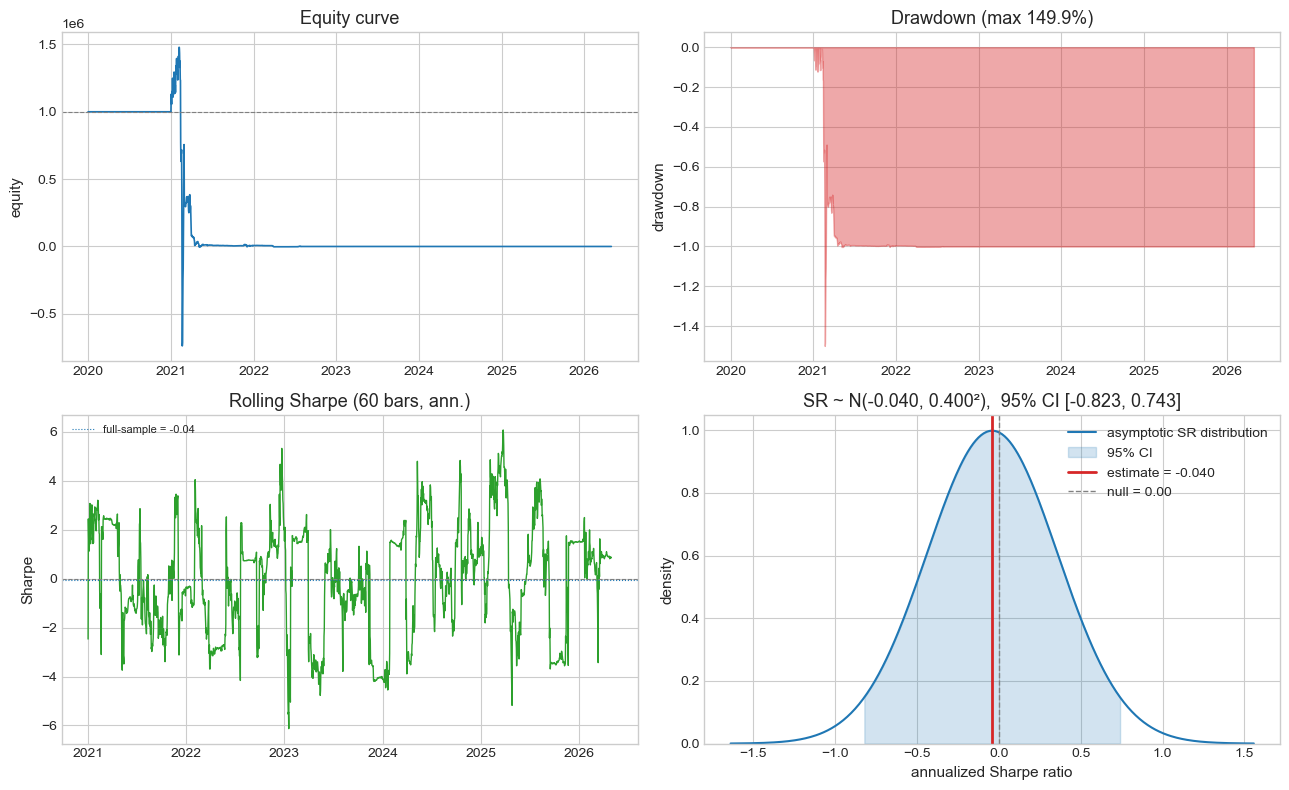

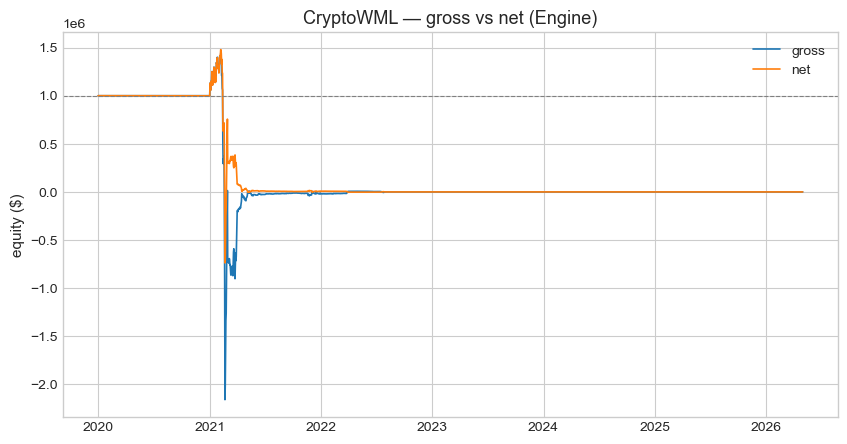


Total costs ($): 22,134
Final gross    : $-0
Final net      : $0

=== (c) Net + 12% vol target (no DD kill switch in engine) ===


Total return,-91.33%
Annualized return,-32.05%
Annualized vol,50.61%
Hit rate,42.06%
Total PnL ($),"-913,272.38"
Total costs ($),"20,379.22"
Gross PnL ($),"-892,893.16"
Turnover (ann.),4.10x
Sharpe (ann.),-0.507
Sharpe SD (ann.),0.405
Sharpe 95% CI,"[-1.300, 0.286]"


Realized ann. vol — net WML     : 1816.32%
Realized ann. vol — vol-target  : 50.61%


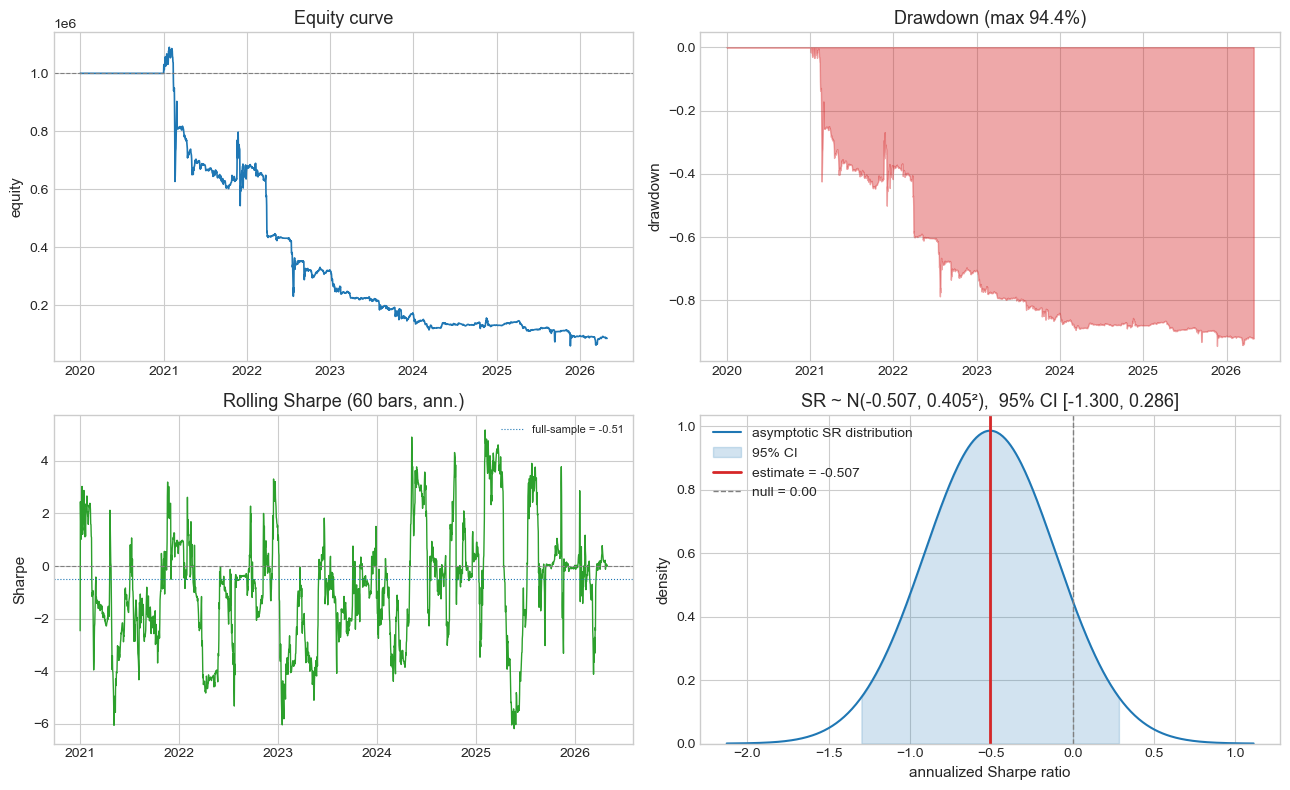

In [17]:
# =============================================================================
# CELL 13 — Single-path Engine (gross vs net-of-costs vs vol-target)
# Stage 3+4: CompositeCostModel + LiquidityCap, then Engine.run().
# Skills: skills/04-costs.md, skills/05-engine-single-path.md
# Depends on: Cells 10–12 (crypto_panel, strat_crypto, BT_START).
# =============================================================================

if "crypto_panel" not in globals() or "strat_crypto" not in globals():
    raise RuntimeError("Run Cells 10–12 first.")

costs_crypto = CompositeCostModel([
    Commission(bps=2),
    Spread(half_bps=2),
    MarketImpact(k=10, kind="sqrt", adv_lookback=20),
    ShortBorrow(annual_bps=300),
])
liq_crypto = LiquidityCap(cap_pct=0.10, adv_lookback=20)

rebal = strat_crypto.rebalance_dates(crypto_panel.dates)
years = len(crypto_panel.dates) / float(ANN_CRYPTO)
print(f"Rebalances: {len(rebal)}  (~{len(rebal)/years:.1f}/yr over {years:.2f}y)")
print(f"Costs: Commission 2bps + Spread 2bps half + sqrt impact k=10 + borrow 300bps/yr")
print(f"Liquidity: 10% ADV cap, lookback=20\n")

# (a) gross — explicit comparison only (PROTOCOL opt-in)
print("=== (a) Gross (no costs) ===")
result_wml_base = Engine(crypto_panel, strat_crypto, initial_capital=INITIAL).run(start=BT_START)
print("metadata:", result_wml_base.metadata)
_ = safe_engine_summary(result_wml_base)

# (b) net — primary backtest
print("\n=== (b) Net (costs + liquidity) ===")
result_wml_net = Engine(
    crypto_panel, strat_crypto,
    costs=costs_crypto, liquidity=liq_crypto, initial_capital=INITIAL,
).run(start=BT_START)
print("metadata:", result_wml_net.metadata)
report_wml_net = safe_metrics_crypto(result_wml_net.returns, result_wml_net.equity_curve, costs=result_wml_net.costs)
if report_wml_net is not None:
    print(f"  Sharpe: {report_wml_net.sharpe:.4f}  Sortino: {report_wml_net.sortino:.4f}")
    print(f"  Max DD: {report_wml_net.max_drawdown:.2%}  Ann vol: {report_wml_net.ann_vol:.2%}")
    print(f"  PSR:    {report_wml_net.psr:.4f}")
_ = safe_engine_summary(result_wml_net)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(result_wml_base.equity_curve.index, result_wml_base.equity_curve, lw=1.2, label="gross")
ax.plot(result_wml_net.equity_curve.index, result_wml_net.equity_curve, lw=1.2, label="net")
ax.axhline(INITIAL, color="gray", ls="--", lw=0.8)
ax.set_title("CryptoWML — gross vs net (Engine)")
ax.set_ylabel("equity ($)")
ax.legend()
plt.show()

print(f"\nTotal costs ($): {result_wml_net.costs.sum():,.0f}")
print(f"Final gross    : ${result_wml_base.equity_curve.iloc[-1]:,.0f}")
print(f"Final net      : ${result_wml_net.equity_curve.iloc[-1]:,.0f}")

# (c) vol-target overlay — RiskConfig has no dd_breaker (engine removed it; source: backtest/risk/config.py)
print("\n=== (c) Net + 12% vol target (no DD kill switch in engine) ===")


class CryptoWMLTV(CryptoWMLStrategy):
    risk = RiskConfig(
        max_position=1.0,
        max_gross=2.0,
        max_net=1.0,
        target_vol=0.12,
        vol_lookback=60,
    )

    def __repr__(self):
        return "CryptoWMLTV()"


result_wml_tv = Engine(
    crypto_panel, CryptoWMLTV(),
    costs=costs_crypto, liquidity=liq_crypto, initial_capital=INITIAL,
).run(start=BT_START)
_ = safe_engine_summary(result_wml_tv)

ann_vol_net = float(result_wml_net.returns.std(ddof=1) * np.sqrt(ANN_CRYPTO))
ann_vol_tv = float(result_wml_tv.returns.std(ddof=1) * np.sqrt(ANN_CRYPTO))
print(f"Realized ann. vol — net WML     : {ann_vol_net:.2%}")
print(f"Realized ann. vol — vol-target  : {ann_vol_tv:.2%}")


In [18]:
# =============================================================================
# CELL 15 — CryptoPMMStrategy + CryptoPMMCStrategy (engine)
# Paper eq. 8–11: asymmetric RPM weights on winner/loser deciles (Cell 6 logic).
# Skill: skills/02-strategy.md
# Depends on: Cells 1, 7 (_compute_rpm optional), 10–12, ohlcv_daily, MKT_SYMBOL.
# =============================================================================

if "CryptoWMLStrategy" not in globals():
    raise RuntimeError("Run Cell 12 first.")
if "ohlcv_daily" not in globals() or MKT_SYMBOL not in ohlcv_daily:
    raise RuntimeError("Need ohlcv_daily and MKT_SYMBOL from Cells 2/2.5.")


def _btc_daily_returns():
    s = ohlcv_daily[MKT_SYMBOL]["close"].sort_index().pct_change().dropna().astype("float64")
    if getattr(s.index, "tz", None) is not None:
        s.index = s.index.tz_convert("UTC")
    return s


_BTC_DAILY_RET = _btc_daily_returns()


def _rpm_rv_at_t(btc_daily: pd.Series, t, window: int, scale: float):
    """RPM+, RPM-, RV at calendar month-end for BTC (same kernel as Cell 7)."""
    ts = pd.Timestamp(t)
    idx = btc_daily.index
    if getattr(idx, "tz", None) is not None:
        ts = ts.tz_localize(idx.tz) if ts.tzinfo is None else ts.tz_convert(idx.tz)
    last_complete = ts.normalize().replace(day=1) - pd.Timedelta(days=1)
    sub = btc_daily.loc[:last_complete]
    if len(sub) < window:
        return float("nan"), float("nan"), float("nan")
    r = sub.values.astype(np.float64)
    pos = len(r) - 1
    start = pos - window + 1
    s_pos = s_neg = 0.0
    for j in range(start, pos + 1):
        r2 = r[j] * r[j]
        if r[j] >= 0.0:
            s_pos += r2
        else:
            s_neg += r2
    rpm_pos = scale * s_pos
    rpm_neg = scale * s_neg
    rv = rpm_pos + rpm_neg
    return rpm_pos, rpm_neg, rv


def _phi_pmm(rpm_pos, rpm_neg, rv, *, capped: bool):
    """Paper phi1/phi2; PMMC rescales when phi1+phi2 > MAX_LEV."""
    if not np.isfinite(rv) or rv <= 0:
        return 0.0, 0.0
    sigma_tar = SIGMA_TAR
    phi1 = 2.0 * sigma_tar / np.sqrt(12.0 * rv) * (rpm_pos / rv)
    phi2 = 2.0 * sigma_tar / np.sqrt(12.0 * rv) * (rpm_neg / rv)
    if capped and (phi1 + phi2) > MAX_LEV:
        phi1 = MAX_LEV * (rpm_pos / rv)
        phi2 = MAX_LEV * (rpm_neg / rv)
    return float(phi1), float(phi2)


class CryptoPMMStrategy(CryptoWMLStrategy):
    """Cross-section WML with PMM leverage: long winners x phi1, short losers x phi2."""

    def __repr__(self):
        return f"CryptoPMMStrategy(form_start={self.form_start}, form_end={self.form_end})"

    def generate_weights(self, data, t):
        z = pd.Series(0.0, index=data.assets)
        eligible = self._eligible_assets(list(data.assets), t, self.form_start)
        if len(eligible) < 10:
            return z
        px = data.prices[eligible].astype("float64")
        if len(px) < 40:
            return z
        daily = px.pct_change().dropna(how="any")
        if len(daily) < 20:
            return z
        daily = self._clip_daily(self._to_timestamp(t), daily)
        if len(daily) < 20:
            return z
        monthly = (1.0 + daily).resample("ME").prod() - 1.0
        monthly.index = monthly.index.to_period("M")
        hold = self._to_timestamp(t).to_period("M")
        form_periods = pd.period_range(hold - self.form_start, hold - self.form_end, freq="M")
        if not form_periods.isin(monthly.index).all():
            return z
        form_block = monthly.reindex(form_periods)
        complete = form_block.columns[form_block.notna().all()].tolist()
        if len(complete) < 10:
            return z
        form_block = form_block[complete]
        mom = (1.0 + form_block).prod(axis=0) - 1.0
        if mom.isnull().any():
            return z
        k_dec = max(1, len(complete) // 10)
        win_syms = mom.nlargest(k_dec).index
        los_syms = mom.nsmallest(k_dec).index

        rpm_pos, rpm_neg, rv = _rpm_rv_at_t(_BTC_DAILY_RET, t, RPM_WINDOW, SCALE)
        phi1, phi2 = _phi_pmm(rpm_pos, rpm_neg, rv, capped=False)
        if phi1 == 0.0 and phi2 == 0.0:
            return z

        w = pd.Series(0.0, index=data.assets)
        w.loc[win_syms] = phi1 / k_dec
        w.loc[los_syms] = -phi2 / k_dec
        return w.reindex(data.assets).fillna(0.0)


class CryptoPMMCStrategy(CryptoPMMStrategy):
    """PMM with 200% gross leverage cap (paper PMMC, eq. 10–11)."""

    def __repr__(self):
        return f"CryptoPMMCStrategy(form_start={self.form_start}, form_end={self.form_end})"

    def generate_weights(self, data, t):
        z = pd.Series(0.0, index=data.assets)
        eligible = self._eligible_assets(list(data.assets), t, self.form_start)
        if len(eligible) < 10:
            return z
        px = data.prices[eligible].astype("float64")
        if len(px) < 40:
            return z
        daily = px.pct_change().dropna(how="any")
        if len(daily) < 20:
            return z
        daily = self._clip_daily(self._to_timestamp(t), daily)
        if len(daily) < 20:
            return z
        monthly = (1.0 + daily).resample("ME").prod() - 1.0
        monthly.index = monthly.index.to_period("M")
        hold = self._to_timestamp(t).to_period("M")
        form_periods = pd.period_range(hold - self.form_start, hold - self.form_end, freq="M")
        if not form_periods.isin(monthly.index).all():
            return z
        form_block = monthly.reindex(form_periods)
        complete = form_block.columns[form_block.notna().all()].tolist()
        if len(complete) < 10:
            return z
        form_block = form_block[complete]
        mom = (1.0 + form_block).prod(axis=0) - 1.0
        if mom.isnull().any():
            return z
        k_dec = max(1, len(complete) // 10)
        win_syms = mom.nlargest(k_dec).index
        los_syms = mom.nsmallest(k_dec).index

        rpm_pos, rpm_neg, rv = _rpm_rv_at_t(_BTC_DAILY_RET, t, RPM_WINDOW, SCALE)
        phi1, phi2 = _phi_pmm(rpm_pos, rpm_neg, rv, capped=True)
        if phi1 == 0.0 and phi2 == 0.0:
            return z

        w = pd.Series(0.0, index=data.assets)
        w.loc[win_syms] = phi1 / k_dec
        w.loc[los_syms] = -phi2 / k_dec
        return w.reindex(data.assets).fillna(0.0)


CryptoPMMStrategy.LISTING_DATES = LISTING_DATES
CryptoPMMStrategy.PIT_UNIVERSE_BY_PERIOD = PIT_UNIVERSE
CryptoPMMCStrategy.LISTING_DATES = LISTING_DATES
CryptoPMMCStrategy.PIT_UNIVERSE_BY_PERIOD = PIT_UNIVERSE

strat_pmm = CryptoPMMStrategy()
strat_pmmc = CryptoPMMCStrategy()

_t_probe = strat_crypto.rebalance_dates(crypto_panel.dates)[-1]
_v = crypto_panel.as_of(_t_probe)
_w_pmm = strat_pmm.generate_weights(_v, _t_probe)
_w_pmmc = strat_pmmc.generate_weights(_v, _t_probe)
print(strat_pmm)
print(strat_pmmc)
print(f"  probe date {_t_probe}:")
print(f"    PMM  gross={_w_pmm.abs().sum():.4f}  net={_w_pmm.sum():.4f}  non-zero={int((_w_pmm!=0).sum())}")
print(f"    PMMC gross={_w_pmmc.abs().sum():.4f}  net={_w_pmmc.sum():.4f}  non-zero={int((_w_pmmc!=0).sum())}")


CryptoPMMStrategy(form_start=12, form_end=2)
CryptoPMMCStrategy(form_start=12, form_end=2)
  probe date 2026-04-01 00:00:00+00:00:
    PMM  gross=0.4503  net=-0.0323  non-zero=6
    PMMC gross=0.4503  net=-0.0323  non-zero=6



  PMM — net (costs + liquidity)
metadata: {'start': Timestamp('2020-01-01 00:00:00+0000', tz='UTC'), 'end': Timestamp('2026-04-30 00:00:00+0000', tz='UTC'), 'initial_capital': 1000000.0, 'n_bars': 2312, 'n_rebalances': 76, 'fit_called': False}
  Sharpe -0.0575  Sortino -0.0601  MaxDD 94.51%  AnnVol 75.89%  PSR 0.4429
  Total costs ($): 32,628
  Final equity   : $125,943


Total return,-87.41%
Annualized return,-27.93%
Annualized vol,75.89%
Hit rate,41.71%
Total PnL ($),"-874,056.69"
Total costs ($),"32,628.41"
Gross PnL ($),"-841,428.28"
Turnover (ann.),4.81x
Sharpe (ann.),-0.057
Sharpe SD (ann.),0.401
Sharpe 95% CI,"[-0.843, 0.728]"



  PMMC — net (costs + liquidity)
metadata: {'start': Timestamp('2020-01-01 00:00:00+0000', tz='UTC'), 'end': Timestamp('2026-04-30 00:00:00+0000', tz='UTC'), 'initial_capital': 1000000.0, 'n_bars': 2312, 'n_rebalances': 76, 'fit_called': False}
  Sharpe -0.0575  Sortino -0.0601  MaxDD 94.51%  AnnVol 75.89%  PSR 0.4429
  Total costs ($): 32,628
  Final equity   : $125,943


Total return,-87.41%
Annualized return,-27.93%
Annualized vol,75.89%
Hit rate,41.71%
Total PnL ($),"-874,056.69"
Total costs ($),"32,628.41"
Gross PnL ($),"-841,428.28"
Turnover (ann.),4.81x
Sharpe (ann.),-0.057
Sharpe SD (ann.),0.401
Sharpe 95% CI,"[-0.843, 0.728]"


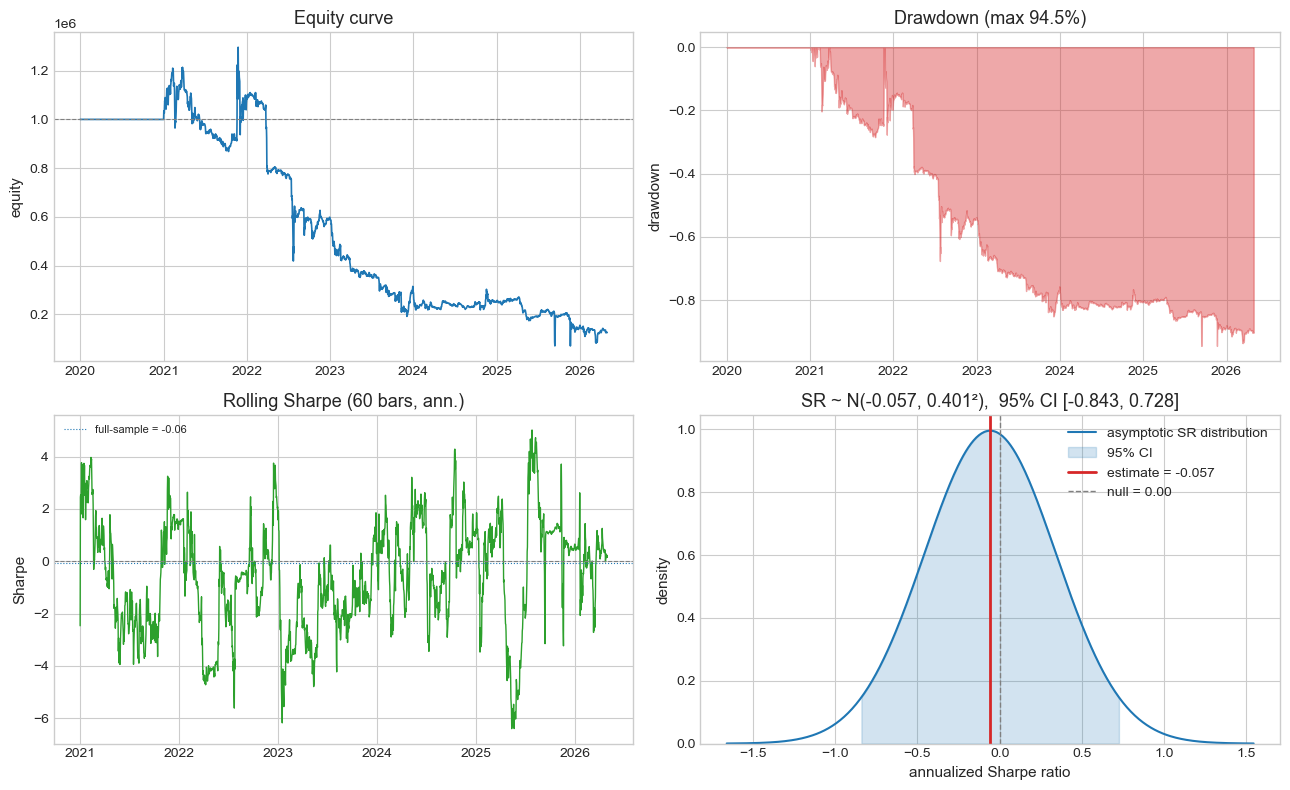

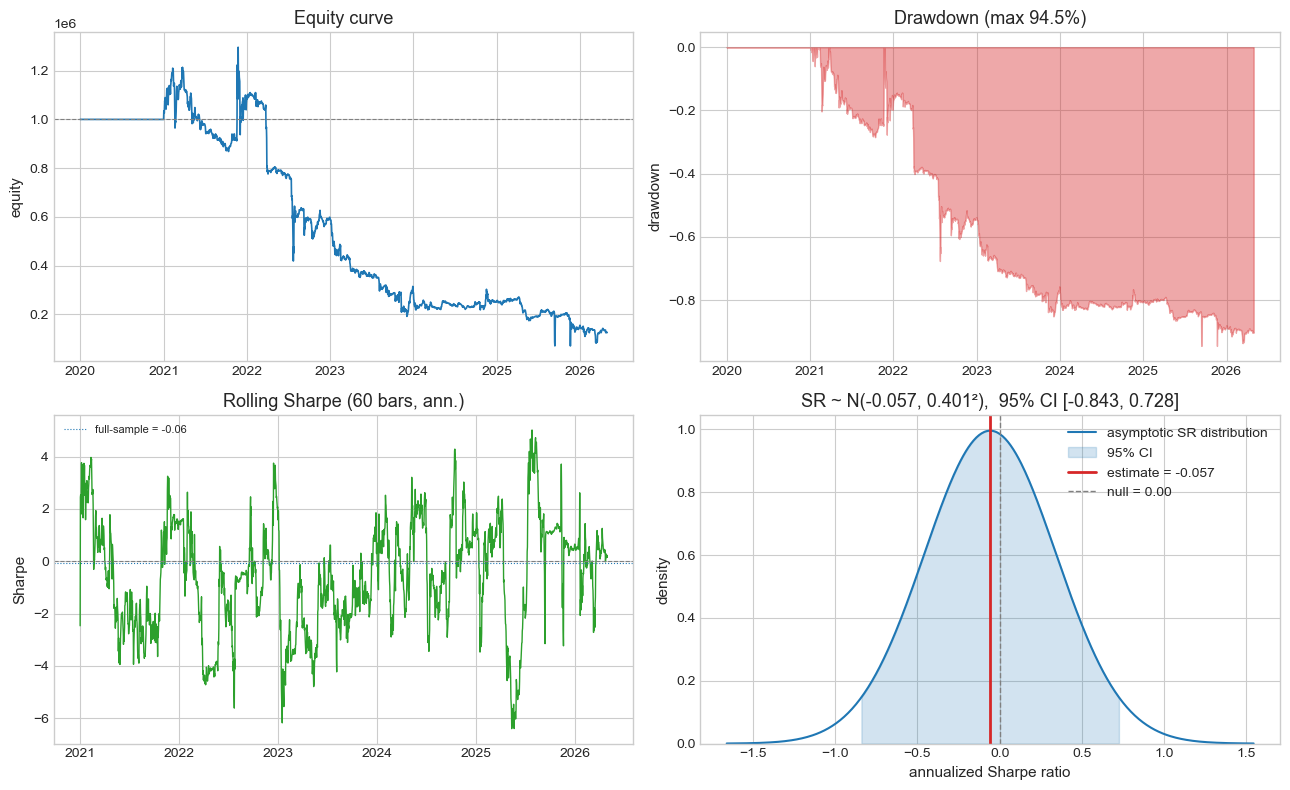

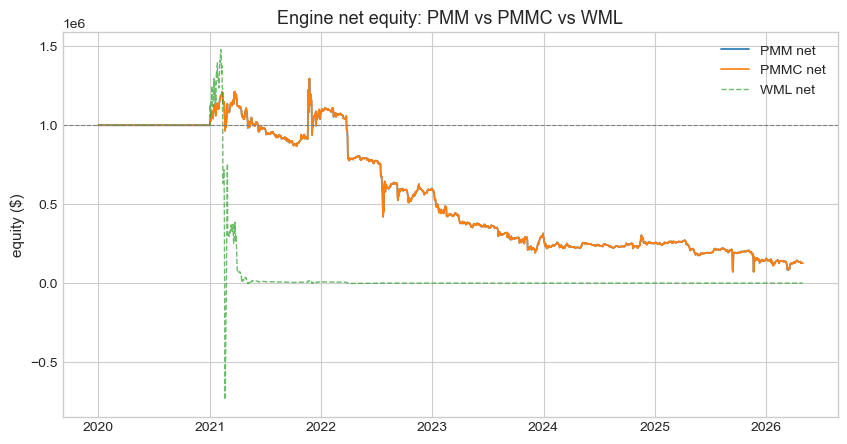

In [19]:
# =============================================================================
# CELL 16 — Engine: PMM + PMMC (net-of-costs)
# Skill: skills/05-engine-single-path.md, skills/04-costs.md
# Depends on: Cell 13 (costs_crypto, liq_crypto), Cell 15 (strat_pmm, strat_pmmc).
# =============================================================================

if "costs_crypto" not in globals() or "liq_crypto" not in globals():
    raise RuntimeError("Run Cell 14 first (defines costs_crypto, liq_crypto).")
if "strat_pmm" not in globals() or "strat_pmmc" not in globals():
    raise RuntimeError("Run Cell 15 first (strat_pmm, strat_pmmc).")

for _label, _strat in [("PMM", strat_pmm), ("PMMC", strat_pmmc)]:
    print(f"\n{'=' * 60}\n  {_label} — net (costs + liquidity)\n{'=' * 60}")
    _res = Engine(
        crypto_panel, _strat,
        costs=costs_crypto, liquidity=liq_crypto, initial_capital=INITIAL,
    ).run(start=BT_START)
    print("metadata:", _res.metadata)
    _rep = safe_metrics_crypto(_res.returns, _res.equity_curve, costs=_res.costs)
    if _rep is not None:
        print(
            f"  Sharpe { _rep.sharpe:.4f}  Sortino {_rep.sortino:.4f}  "
            f"MaxDD {_rep.max_drawdown:.2%}  AnnVol {_rep.ann_vol:.2%}  PSR {_rep.psr:.4f}"
        )
    print(f"  Total costs ($): {_res.costs.sum():,.0f}")
    print(f"  Final equity   : ${_res.equity_curve.iloc[-1]:,.0f}")
    _ = safe_engine_summary(_res)
    if _label == "PMM":
        result_pmm_net = _res
    else:
        result_pmmc_net = _res

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(result_pmm_net.equity_curve.index, result_pmm_net.equity_curve, lw=1.2, label="PMM net")
ax.plot(result_pmmc_net.equity_curve.index, result_pmmc_net.equity_curve, lw=1.2, label="PMMC net")
if "result_wml_net" in globals():
    ax.plot(result_wml_net.equity_curve.index, result_wml_net.equity_curve, lw=1.0, ls="--", alpha=0.7, label="WML net")
ax.axhline(INITIAL, color="gray", ls="--", lw=0.8)
ax.set_title("Engine net equity: PMM vs PMMC vs WML")
ax.set_ylabel("equity ($)")
ax.legend()
plt.show()
